In [19]:
import numpy as np

data = np.load("/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_test_normal.npz")

print(data.files)

['X', 'H', 'scan_ids']


In [ ]:
import numpy as np

data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_2d.npz",
    allow_pickle=True
)

scan_ids = data["scan_ids"]

unique_scans = np.unique(scan_ids)

print("Number of unique scans:", len(unique_scans))

for s in unique_scans:
    print(s)

Number of unique scans: 82
train_10938_a_1
train_10991_a_1
train_11023_b_1
train_11150_b_2
train_11164_b_2
train_1119_b_2
train_11522_a_1
train_11880_d_1
train_1188_c_2
train_1192_a_2
train_1213_a_2
train_122_b_1
train_12309_a_1
train_12563_e_1
train_1292_b_2
train_1310_b_2
train_1329_b_1
train_13316_a_2
train_1348_g_2
train_1405_a_2
train_1409_a_2
train_1448_c_2
train_1496_a_1
train_1504_b_2
train_1540_a_1
train_1560_a_2
train_1591_c_2
train_1686_a_1
train_1756_a_1
train_1758_a_2
train_1758_b_2
train_1767_a_2
train_1868_a_2
train_186_a_2
train_1976_a_2
train_2167_a_2
train_2319_a_1
train_2806_a_2
train_2857_a_1
train_2886_a_2
train_2965_b_2
train_2986_c_2
train_2993_a_2
train_340_a_1
train_355_a_1
train_412_b_2
train_5231_a_2
train_5529_a_2
train_5822_a_2
train_5895_a_2
train_6335_b_1
train_6429_a_1
train_644_b_2
train_644_c_2
train_644_d_1
train_6629_a_1
train_6671_a_2
train_6970_a_2
train_6970_b_2
train_7062_a_2
train_7139_a_1
train_7145_a_2
train_7244_a_1
train_7250_b_2
train_7250_

In [3]:
import numpy as np

data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_2d.npz",
    allow_pickle=True
)

scan_ids = data["scan_ids"]

unique_scans, counts = np.unique(
    scan_ids,
    return_counts=True
)

# Sort by least number of patches
least_idx = np.argsort(counts)

print("Scans with the fewest patches:\n")

for i in least_idx[:20]:   # show 20 least frequent scans
    print(f"{unique_scans[i]} : {counts[i]} patches")

Scans with the fewest patches:

train_8072_a_2 : 1 patches
train_12563_e_1 : 4 patches
train_6671_a_2 : 5 patches
valid_918_a_2 : 7 patches
train_1591_c_2 : 8 patches
train_7674_a_2 : 10 patches
train_11150_b_2 : 12 patches
train_7250_b_2 : 14 patches
train_1976_a_2 : 14 patches
train_1540_a_1 : 16 patches
train_355_a_1 : 18 patches
train_10991_a_1 : 18 patches
train_913_a_1 : 19 patches
train_7250_f_2 : 19 patches
train_1188_c_2 : 20 patches
train_6429_a_1 : 23 patches
train_7250_i_2 : 23 patches
train_2886_a_2 : 24 patches
train_1868_a_2 : 26 patches
train_2806_a_2 : 27 patches


In [4]:
import numpy as np

data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_2d.npz",
    allow_pickle=True
)

X = data["X"]
scan_ids = data["scan_ids"]
coords = data["coords"]
H = data["H"]

target_scan = "train_11150_b_2"

# Find patch indices
indices = np.where(scan_ids == target_scan)[0]

print("Number of patches:", len(indices))
print("Patch matrix column indices:")
print(indices)

Number of patches: 12
Patch matrix column indices:
[11751 11752 11753 11754 11755 11756 11757 11758 11759 11760 11761 11762]


In [5]:
coords = data["coords"]
scan_ids = data["scan_ids"]
scan_id = "train_11150_b_2"
indices = np.where(
    scan_ids == scan_id
)[0]

print("Indices:")
print(indices)

print("\nCoordinates:")
print(coords[indices])

Indices:
[11751 11752 11753 11754 11755 11756 11757 11758 11759 11760 11761 11762]

Coordinates:
[[ 61 158 116]
 [ 61 158 120]
 [ 65 154 116]
 [ 65 154 120]
 [ 65 158 112]
 [ 65 158 116]
 [ 65 158 120]
 [ 65 162 116]
 [ 65 162 120]
 [ 69 158 116]
 [ 69 158 120]
 [ 69 162 116]]


['Gamma', 'labels']
Indices:
[11751 11752 11753 11754 11755 11756 11757 11758 11759 11760 11761 11762]

Coordinates:
[[ 61 158 116]
 [ 61 158 120]
 [ 65 154 116]
 [ 65 154 120]
 [ 65 158 112]
 [ 65 158 116]
 [ 65 158 120]
 [ 65 162 116]
 [ 65 162 120]
 [ 69 158 116]
 [ 69 158 120]
 [ 69 162 116]]
(1728, 12)
(12, 12, 12, 12)


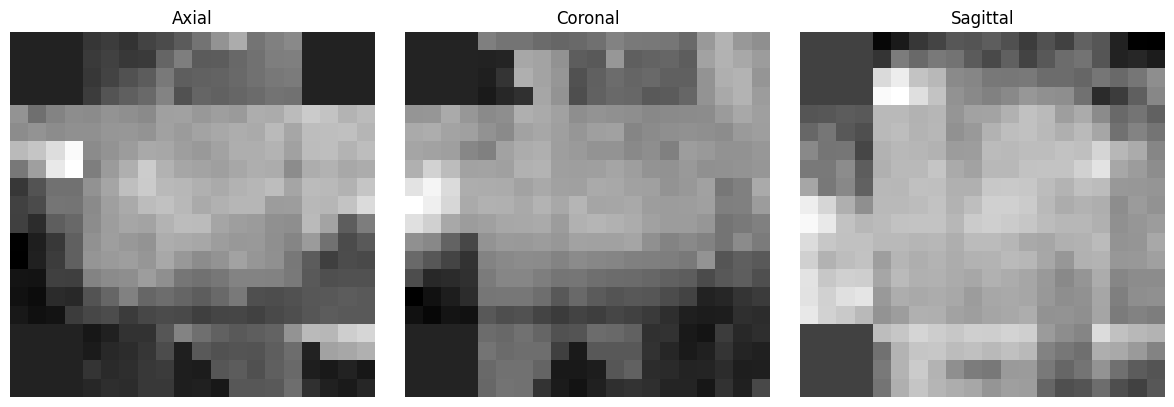

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

with open(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/models/unified_frozen.pkl",
    "rb"
) as f:
    model_data = pickle.load(f)

ksvd = model_data["model"]
D = ksvd.D_

sparse_codes = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/sparse_codes/train_sparse_codes_frozen.npz",
    allow_pickle=True
)
print(sparse_codes.files)

patch_data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_2d.npz",
    allow_pickle=True
)

X = patch_data["X"]
scan_ids = patch_data["scan_ids"]
coords = patch_data["coords"]
H = patch_data["H"]

target_scan = "train_11150_b_2"

Gamma = sparse_codes["Gamma"]
labels = sparse_codes["labels"]

# Find the patches that actually belong to the target scan
indices = np.where(scan_ids == target_scan)[0]

print("Indices:")
print(indices)

print("\nCoordinates:")
print(coords[indices])

# Reconstruct exactly those patches, using the same indices
gamma = Gamma[:, indices]
reconstructed = D @ gamma

print(reconstructed.shape)

patches = reconstructed.T.reshape(-1, 12, 12, 12)
print(patches.shape)

min_coord = coords[indices].min(axis=0)
max_coord = coords[indices].max(axis=0)

shape = tuple(max_coord - min_coord + 12)

volume = np.zeros(shape)
weight = np.zeros(shape)

for patch, coord in zip(patches, coords[indices]):
    x, y, z = coord - min_coord
    volume[x:x+12, y:y+12, z:z+12] += patch
    weight[x:x+12, y:y+12, z:z+12] += 1

volume /= np.maximum(weight, 1)

# Visualize the reconstructed volume
cx, cy, cz = np.array(volume.shape) // 2

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(volume[:, :, cz], cmap="gray")
ax[0].set_title("Axial")

ax[1].imshow(volume[:, cy, :], cmap="gray")
ax[1].set_title("Coronal")

ax[2].imshow(volume[cx, :, :], cmap="gray")
ax[2].set_title("Sagittal")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()


lungmask 2026-07-23 23:20:19 Postprocessing
Volume shape: (219, 219, 203)
Finding map: {0: '2d'}


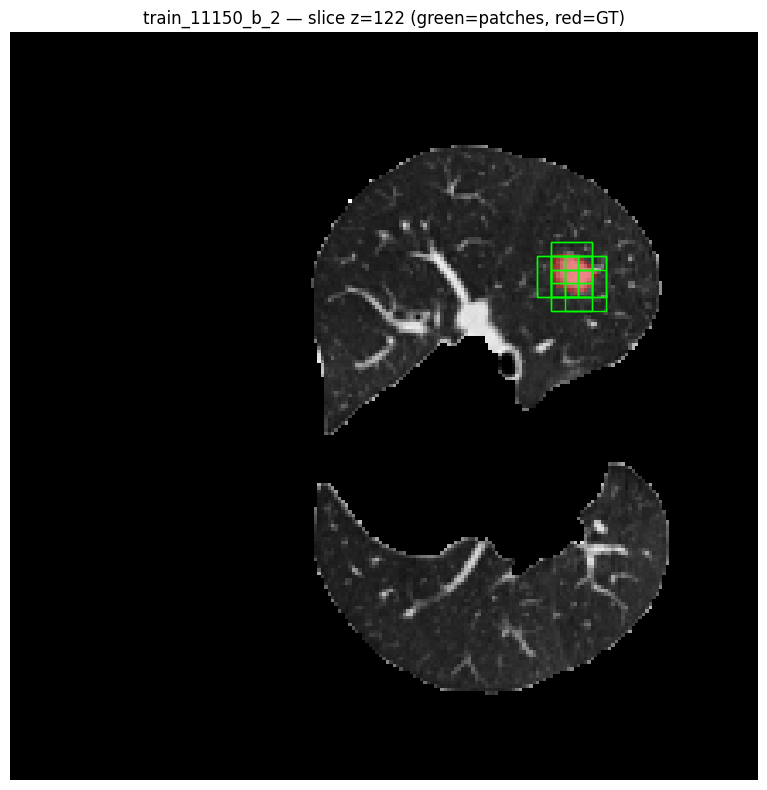

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from lc_ksvd.data_loader.metadata_registry import MetadataRegistry
from lc_ksvd.data_loader.scan_loader import ScanLoader
from lc_ksvd.config import PATCH_SIZE, CLASS_ORDER

target_scan = "train_11150_b_2"
split = "train"   # matches the "train_" prefix / patch file split

# --- Load the actual preprocessed volume + resampled ground-truth mask ---
metadata = MetadataRegistry(split=split)
scan = ScanLoader(metadata).load(target_scan)

volume = scan["volume"]          # float32 [H, W, D] in [0, 1], resampled/windowed
mask = scan["mask"]              # uint8 [F, H, W, D] or None, same grid as volume
finding_map = scan["finding_map"]  # {f_idx: category}, e.g. {0: "2c"}

print("Volume shape:", volume.shape)
print("Finding map:", finding_map)

# --- Patch coords for this scan (already in the same coordinate space as volume) ---
patch_data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_2d.npz",
    allow_pickle=True,
)
scan_ids = patch_data["scan_ids"]
coords = patch_data["coords"]

indices = np.where(scan_ids == target_scan)[0]
scan_coords = coords[indices]

# --- Collapse ground truth mask (any finding) into a single binary volume ---
gt = None
if mask is not None:
    gt = mask.any(axis=0)  # [H, W, D] bool, union over all findings

# --- Pick a slice to visualize: center of the patch cloud along z ---
if len(scan_coords) > 0:
    cz = int(np.median(scan_coords[:, 2] + PATCH_SIZE // 2))
else:
    cz = volume.shape[2] // 2

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(volume[:, :, cz], cmap="gray")

# Overlay ground truth mask (red, semi-transparent)
if gt is not None:
    gt_slice = gt[:, :, cz]
    overlay = np.zeros((*gt_slice.shape, 4))
    overlay[gt_slice] = [1, 0, 0, 0.4]  # red, alpha 0.4
    ax.imshow(overlay)

# Overlay patch boxes that intersect this slice
for (x0, y0, z0) in scan_coords:
    if z0 <= cz < z0 + PATCH_SIZE:
        rect = mpatches.Rectangle(
            (y0, x0), PATCH_SIZE, PATCH_SIZE,
            linewidth=1, edgecolor="lime", facecolor="none",
        )
        ax.add_patch(rect)

ax.set_title(f"{target_scan} — slice z={cz} (green=patches, red=GT)")
ax.axis("off")
plt.tight_layout()
plt.show()


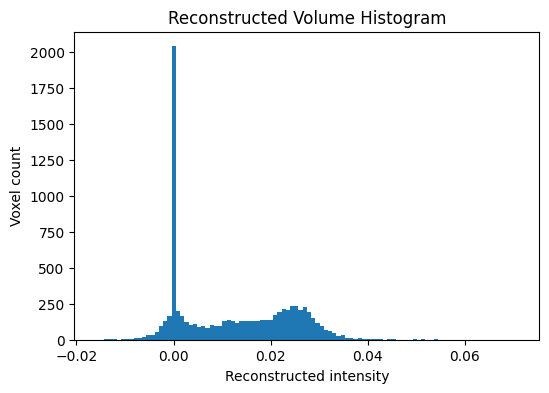

min: -0.016070490702986717
max: 0.07103092223405838
mean: 0.012017461376362443
std: 0.011870153876053818


In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(volume.flatten(), bins=100)
plt.xlabel("Reconstructed intensity")
plt.ylabel("Voxel count")
plt.title("Reconstructed Volume Histogram")
plt.show()

print("min:", volume.min())
print("max:", volume.max())
print("mean:", volume.mean())
print("std:", volume.std())

In [39]:
# choose threshold
threshold = np.percentile(volume[volume != 0], 50)

print("Threshold:", threshold)

segmentation = volume > threshold

print("Foreground voxels:", segmentation.sum())

Threshold: 0.01717256521806121
Foreground voxels: 3072


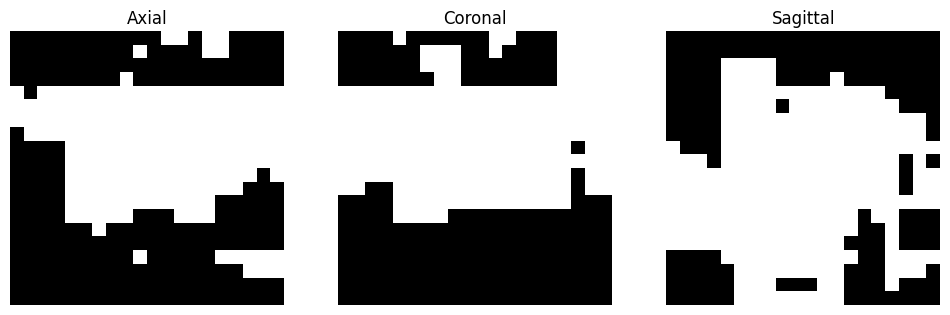

In [40]:
cx, cy, cz = np.array(segmentation.shape)//2

fig, ax = plt.subplots(1,3,figsize=(12,4))

ax[0].imshow(segmentation[:,:,cz], cmap="gray")
ax[0].set_title("Axial")

ax[1].imshow(segmentation[:,cy,:], cmap="gray")
ax[1].set_title("Coronal")

ax[2].imshow(segmentation[cx,:,:], cmap="gray")
ax[2].set_title("Sagittal")

for a in ax:
    a.axis("off")

plt.show()

In [8]:
from skimage.filters import threshold_otsu

nonzero = volume[volume != 0]

threshold = threshold_otsu(nonzero)

print("Otsu threshold:", threshold)

segmentation = volume > threshold

Otsu threshold: 0.014040739941265201


In [9]:
from scipy.ndimage import binary_opening, binary_closing, label
from scipy.ndimage import label

segmentation = binary_opening(
    segmentation,
    iterations=1
)

segmentation = binary_closing(
    segmentation,
    iterations=2
)

labeled, num = label(segmentation)

sizes = np.bincount(labeled.ravel())

# remove background
sizes[0] = 0

largest_component = sizes.argmax()

segmentation = labeled == largest_component

print(
    "Final segmentation voxels:",
    segmentation.sum()
)

Final segmentation voxels: 2480


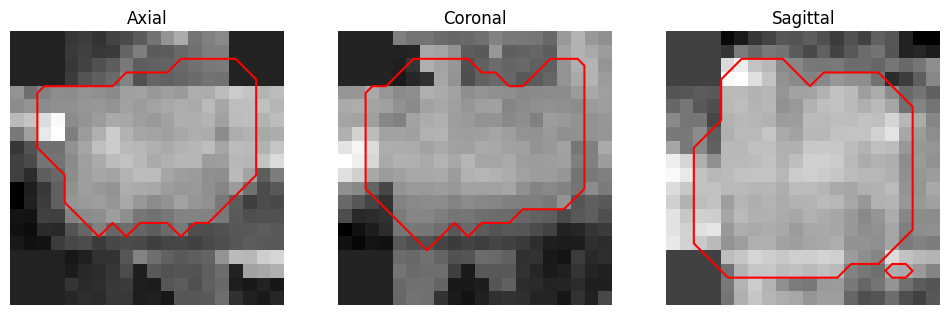

In [29]:
cx,cy,cz = np.array(volume.shape)//2

fig,ax = plt.subplots(1,3,figsize=(12,4))

ax[0].imshow(volume[:,:,cz], cmap="gray")
ax[0].contour(segmentation[:,:,cz], colors="red")
ax[0].set_title("Axial")

ax[1].imshow(volume[:,cy,:], cmap="gray")
ax[1].contour(segmentation[:,cy,:], colors="red")
ax[1].set_title("Coronal")

ax[2].imshow(volume[cx,:,:], cmap="gray")
ax[2].contour(segmentation[cx,:,:], colors="red")
ax[2].set_title("Sagittal")

for a in ax:
    a.axis("off")

plt.show()

In [11]:
import nibabel as nib
import os

# Convert boolean mask to uint8
segmentation_uint8 = segmentation.astype(np.uint16)

# Save path
save_path = f"/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/reconstructed/{scan_id}.nii.gz"

# Create identity affine (because this is a cropped reconstruction)
affine = np.eye(4)

# Create NIfTI image
nii = nib.Nifti1Image(
    segmentation_uint8,
    affine
)

# Save
nib.save(
    nii,
    save_path
)

print("Saved segmentation:")
print(save_path)

print("Shape:", segmentation_uint8.shape)
print("Foreground voxels:", segmentation_uint8.sum())

Saved segmentation:
/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/reconstructed/train_11150_b_2.nii.gz
Shape: (20, 20, 20)
Foreground voxels: 2480


In [ ]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import SimpleITK as sitk
from lungmask import LMInferer


# ============================================================
# Paths
# ============================================================

ct_path = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_11150_b_2.nii.gz"

pred_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/reconstructed/train_11150_b_2.nii.gz"

gt_path = "/home/chest_ct/code/data/segmentations/segmentations/train_11150_b_2.nii.gz"



# ============================================================
# Load CT (reference image)
# ============================================================

ct_img = nib.load(ct_path)

ct = np.asarray(
    ct_img.dataobj,
    dtype=np.float32
)

print("CT shape:", ct.shape)
print("CT orientation:", nib.aff2axcodes(ct_img.affine))


# ============================================================
# Load GT channel 0
# ============================================================

gt_img = nib.load(gt_path)

gt_raw = np.asarray(
    gt_img.dataobj
)

print("Original GT:", gt_raw.shape)
print("GT orientation:", nib.aff2axcodes(gt_img.affine))


# take channel 0 only
if gt_raw.ndim == 4:
    gt_raw = gt_raw[0]


gt_raw = (gt_raw > 0).astype(np.uint8)


# ============================================================
# Resample GT into CT space
# ============================================================

# Convert CT to SimpleITK
ct_sitk = sitk.ReadImage(ct_path)


# Convert GT to SimpleITK
# nibabel array is (x,y,z), SimpleITK expects (z,y,x)
gt_sitk = sitk.GetImageFromArray(
    np.transpose(gt_raw, (2,1,0))
)


# Copy GT spacing approximately from original GT
gt_spacing = gt_img.header.get_zooms()

gt_sitk.SetSpacing(
    tuple(gt_spacing)
)


# Resample GT -> CT grid
resampler = sitk.ResampleImageFilter()

resampler.SetReferenceImage(ct_sitk)

resampler.SetInterpolator(
    sitk.sitkNearestNeighbor
)

resampler.SetDefaultPixelValue(0)


gt_resampled = resampler.Execute(
    gt_sitk
)


# Back to numpy (x,y,z)
gt = sitk.GetArrayFromImage(
    gt_resampled
)

gt = np.transpose(
    gt,
    (2,1,0)
)

gt = (gt > 0).astype(np.uint8)


print("Aligned GT:", gt.shape)
print("Aligned GT voxels:", gt.sum())



# ============================================================
# Lung segmentation
# ============================================================

inferer = LMInferer(
    tqdm_disable=True
)

ct_sitk_for_lung = sitk.ReadImage(ct_path)


lung = inferer.apply(
    ct_sitk_for_lung
)


lung = sitk.GetArrayFromImage(
    lung
)

lung = np.transpose(
    lung > 0,
    (2,1,0)
)


print("Lung:", lung.shape)



# ============================================================
# Load prediction
# ============================================================

pred_crop = np.asarray(
    nib.load(pred_path).dataobj
)

pred_crop = pred_crop > 0


print("Prediction crop:", pred_crop.shape)



# ============================================================
# Put prediction into CT coordinates
# ============================================================

coords12 = np.array([
    [61,158,116],
    [61,158,120],
    [65,154,116],
    [65,154,120],
    [65,158,112],
    [65,158,116],
    [65,158,120],
    [65,162,116],
    [65,162,120],
    [69,158,116],
    [69,158,120],
    [69,162,116]
])


min_coord = coords12.min(axis=0)

print("Prediction origin:", min_coord)


pred = np.zeros_like(
    ct,
    dtype=np.uint8
)


x,y,z = min_coord


pred[
    x:x+pred_crop.shape[0],
    y:y+pred_crop.shape[1],
    z:z+pred_crop.shape[2]
] = pred_crop.astype(np.uint8)


print("Prediction voxels:", pred.sum())



# ============================================================
# Find best GT slice
# ============================================================

gt_per_slice = gt.sum(axis=(0,1))

slice_id = np.argmax(
    gt_per_slice
)


print(
    "Best slice:",
    slice_id,
    "GT voxels:",
    gt_per_slice[slice_id]
)



# ============================================================
# Visualization
# ============================================================

plt.figure(figsize=(18,5))


# CT

plt.subplot(1,3,1)

plt.imshow(
    ct[:,:,slice_id],
    cmap="gray"
)

plt.title(
    f"CT slice {slice_id}"
)

plt.axis("off")



# Lung

plt.subplot(1,3,2)

plt.imshow(
    ct[:,:,slice_id],
    cmap="gray"
)

plt.contour(
    lung[:,:,slice_id],
    colors="cyan"
)

plt.title(
    "CT + Lung mask"
)

plt.axis("off")



# GT vs Prediction

plt.subplot(1,3,3)

plt.imshow(
    ct[:,:,slice_id],
    cmap="gray"
)


plt.contour(
    gt[:,:,slice_id],
    colors="lime",
    linewidths=2
)


plt.contour(
    pred[:,:,slice_id],
    colors="red",
    linewidths=2
)


plt.title(
    "GT channel 0 (green) vs Prediction (red)"
)

plt.axis("off")


plt.tight_layout()
plt.show()

CT shape: (512, 512, 244)
CT orientation: ('L', 'P', 'S')
Original GT: (3, 512, 512, 244)
GT orientation: ('R', 'A', 'S')


TypeError: in method 'Image_SetSpacing', argument 2 of type 'std::vector< double,std::allocator< double > > const &'

In [19]:
import nibabel as nib
import numpy as np


# ============================================================
# Paths
# ============================================================

ct_path = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_11150_b_2.nii.gz"

pred_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/reconstructed/train_11150_b_2.nii.gz"

gt_path = "/home/chest_ct/code/data/segmentations/segmentations/train_11150_b_2.nii.gz"



def inspect_nifti(name, path):

    img = nib.load(path)

    data = np.asarray(img.dataobj)

    print("="*60)
    print(name)
    print("="*60)

    print("Shape:")
    print(data.shape)

    print("\nVoxel spacing:")
    print(img.header.get_zooms())

    print("\nOrientation:")
    print(nib.aff2axcodes(img.affine))

    print("\nAffine:")
    print(img.affine)

    print("\nData type:")
    print(data.dtype)

    print("\nNon-zero voxels:")
    print(np.count_nonzero(data))

    print("\nValue range:")
    print(data.min(), "to", data.max())

    print()



# ============================================================
# Inspect all
# ============================================================

inspect_nifti(
    "CT",
    ct_path
)


inspect_nifti(
    "GROUND TRUTH",
    gt_path
)


inspect_nifti(
    "PREDICTION",
    pred_path
)

CT
Shape:
(512, 512, 244)

Voxel spacing:
(np.float32(0.64226174), np.float32(0.64226174), np.float32(1.25))

Orientation:
('L', 'P', 'S')

Affine:
[[-6.42261744e-01  0.00000000e+00  0.00000000e+00  1.75178864e+02]
 [ 0.00000000e+00 -6.42261744e-01  0.00000000e+00  3.63597870e+02]
 [ 0.00000000e+00  0.00000000e+00  1.25000000e+00 -1.18412598e+03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Data type:
int16

Non-zero voxels:
63860776

Value range:
-1156 to 2351

GROUND TRUTH
Shape:
(3, 512, 512, 244)

Voxel spacing:
(np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(0.0))

Orientation:
('R', 'A', 'S')

Affine:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

Data type:
uint8

Non-zero voxels:
25969

Value range:
0 to 1

PREDICTION
Shape:
(20, 20, 20)

Voxel spacing:
(np.float32(1.0), np.float32(1.0), np.float32(1.0))

Orientation:
('R', 'A', 'S')

Affine:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

Data type:
uint16

No

In [20]:
import nibabel as nib
import numpy as np

gt_img = nib.load(gt_path)

gt = gt_img.get_fdata()

# channel 0
gt0 = gt[0]

coords = np.argwhere(gt0 > 0)

print("GT min coords:", coords.min(axis=0))
print("GT max coords:", coords.max(axis=0))
print("GT size:", coords.max(axis=0)-coords.min(axis=0)+1)

GT min coords: [149 368 143]
GT max coords: [178 401 153]
GT size: [30 34 11]


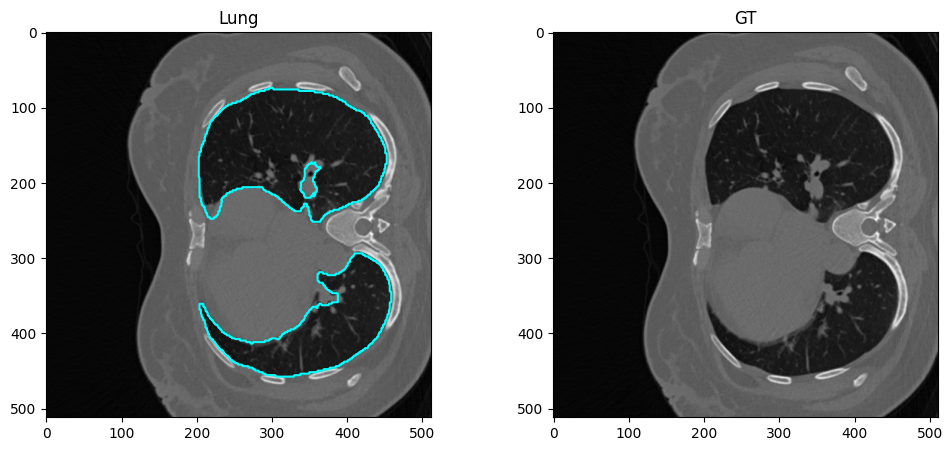

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(ct[:,:,slice_id], cmap="gray")
plt.contour(
    lung[:,:,slice_id],
    colors="cyan"
)
plt.title("Lung")

plt.subplot(1,2,2)
plt.imshow(ct[:,:,slice_id], cmap="gray")
plt.contour(
    gt[:,:,slice_id],
    colors="lime"
)
plt.title("GT")

plt.show()

Prediction max slice: 118 Pred voxels: 200
GT voxels on prediction slice: 0


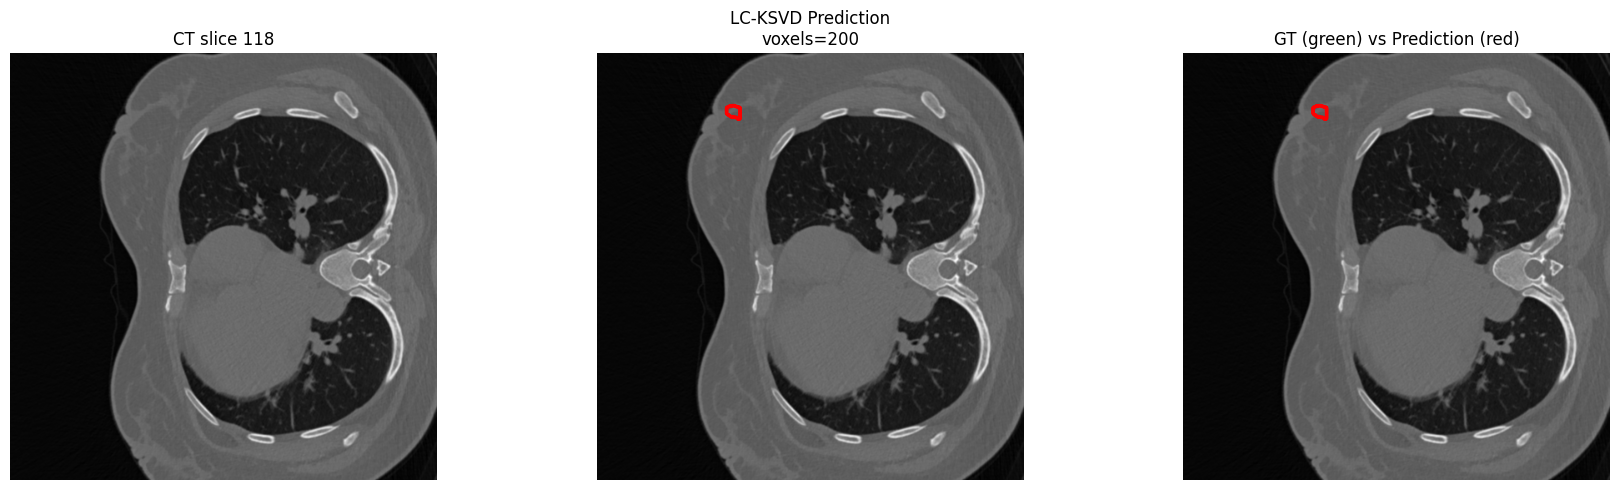

In [14]:
# ============================================================
# Find slice with maximum predicted voxels
# ============================================================

pred_per_slice = pred.sum(axis=(0,1))

pred_slice = np.argmax(pred_per_slice)

print(
    "Prediction max slice:",
    pred_slice,
    "Pred voxels:",
    pred_per_slice[pred_slice]
)


# Also print GT voxels on this slice
print(
    "GT voxels on prediction slice:",
    gt[:,:,pred_slice].sum()
)


# ============================================================
# Visualize prediction max slice
# ============================================================

slice_id = pred_slice


plt.figure(figsize=(18,5))


# CT
plt.subplot(1,3,1)

plt.imshow(
    ct[:,:,slice_id],
    cmap="gray"
)

plt.title(
    f"CT slice {slice_id}"
)

plt.axis("off")



# Prediction only
plt.subplot(1,3,2)

plt.imshow(
    ct[:,:,slice_id],
    cmap="gray"
)

plt.contour(
    pred[:,:,slice_id],
    colors="red",
    linewidths=2
)

plt.title(
    f"LC-KSVD Prediction\nvoxels={pred_per_slice[slice_id]}"
)

plt.axis("off")



# Prediction + GT
plt.subplot(1,3,3)

plt.imshow(
    ct[:,:,slice_id],
    cmap="gray"
)


# GT green
plt.contour(
    gt[:,:,slice_id],
    colors="lime",
    linewidths=2
)


# Prediction red
plt.contour(
    pred[:,:,slice_id],
    colors="red",
    linewidths=2
)


plt.title(
    "GT (green) vs Prediction (red)"
)

plt.axis("off")


plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import collections
from scipy import sparse
import networkx as nx

data = np.load('src/lc_ksvd/outputs/sparse_codes/train_sparse_codes_frozen.npz')
Gamma = data['Gamma']       # (n_atoms, n_samples) sparse code matrix
labels = data['labels']     # (n_samples,) class labels

nz = (Gamma != 0)
nnz_per_col = nz.sum(axis=0)

print('Gamma shape:', Gamma.shape)
print('nnz per sample: min', nnz_per_col.min(), 'max', nnz_per_col.max(), 'mean', nnz_per_col.mean())
print(collections.Counter(nnz_per_col.tolist()))


Gamma shape: (12096, 118705)
nnz per sample: min 0 max 10 mean 9.390505875910872
Counter({10: 111470, 0: 7235})


In [5]:
atom_freq = nz.sum(axis=1)      # how many samples use each atom
order = np.argsort(-atom_freq)

n = Gamma.shape[1]
print('Top 15 most-used atoms:')
for i in order[:15]:
    print(i, int(atom_freq[i]), f'{100*atom_freq[i]/n:.2f}%')

print('atom usage stats: min', atom_freq.min(), 'max', atom_freq.max(), 'mean', atom_freq.mean())


Top 15 most-used atoms:
6498 14209 11.97%
9300 2439 2.05%
8808 1846 1.56%
7573 1822 1.53%
9877 1800 1.52%
9631 1526 1.29%
1441 1521 1.28%
10402 1517 1.28%
10181 1503 1.27%
4834 1391 1.17%
1333 1355 1.14%
10083 1350 1.14%
9372 1336 1.13%
9323 1325 1.12%
9830 1298 1.09%
atom usage stats: min 1 max 14209 mean 92.15443121693121


In [6]:
mask = nnz_per_col == 10
idx_cols = np.where(mask)[0]

combo_counter = collections.Counter()
for j in idx_cols:
    combo = tuple(np.nonzero(Gamma[:, j])[0].tolist())
    combo_counter[combo] += 1

print('unique exact combos:', len(combo_counter), '/', mask.sum())
for combo, cnt in combo_counter.most_common(10):
    print(cnt, combo)


unique exact combos: 111382 / 111470
10 (1549, 2321, 5897, 6037, 6574, 6595, 10768, 11183, 11396, 11635)
8 (867, 1181, 1604, 1814, 4127, 6128, 6386, 10992, 11515, 11558)
7 (1706, 2991, 3309, 3402, 4346, 6125, 6394, 9767, 10968, 12008)
7 (981, 2511, 2792, 3266, 3738, 4562, 5414, 10557, 10713, 11681)
5 (180, 699, 1435, 2931, 5366, 6279, 7414, 9917, 10527, 11576)
5 (991, 1146, 1174, 1791, 3027, 4797, 5166, 10127, 11423, 11873)
3 (2931, 4007, 4323, 8599, 10469, 11081, 11467, 11610, 11913, 11926)
3 (1966, 2665, 3145, 3541, 3841, 5166, 5667, 11072, 11896, 12019)
3 (1181, 1679, 4006, 4563, 8877, 9323, 9897, 10894, 11026, 11515)
3 (760, 1808, 2511, 2629, 2792, 3738, 4631, 6546, 10713, 11767)


In [7]:
HUB = 6498  # exclude the outlier atom so it doesn't drown out every pair
nz_sp = sparse.csr_matrix(nz.astype(np.int32))

keep = np.where(atom_freq >= 50)[0]     # restrict to atoms used often enough to matter
keep = keep[keep != HUB]

sub = nz_sp[keep, :]
co = sub.dot(sub.T).tocoo()             # co-occurrence count matrix (atoms x atoms)
mask = co.row != co.col
rows, cols, vals = co.row[mask], co.col[mask], co.data[mask]

order = np.argsort(-vals)
seen = set()
print('Top 20 co-occurring atom pairs (excluding hub):')
c = 0
for k in order:
    i, j = keep[rows[k]], keep[cols[k]]
    key = tuple(sorted((int(i), int(j))))
    if key in seen: 
        continue
    seen.add(key)
    print(key, int(vals[k]))
    c += 1
    if c >= 20:
        break


Top 20 co-occurring atom pairs (excluding hub):
(4631, 10713) 95
(635, 1010) 89
(1010, 6212) 86
(5061, 9631) 83
(10713, 11767) 81
(360, 1441) 80
(360, 1333) 76
(10768, 11396) 75
(1441, 10402) 74
(5366, 5614) 74
(7573, 8818) 73
(1333, 1441) 73
(1441, 3424) 71
(10713, 11941) 70
(3472, 9877) 70
(1441, 6464) 69
(1679, 4563) 68
(5061, 11463) 68
(9877, 11442) 68
(10978, 11463) 67


(4219, 4219)
4726  5523    0.254787
4463  6116    0.234862
546   5857    0.225851
6342  8749    0.205823
2747  4441    0.205321
283   5523    0.204985
1600  5857    0.203272
3248  6785    0.201440
5769  6342    0.191651
2994  4726    0.190070
3     6811    0.188549
2441  4738    0.183127
438   6785    0.183025
283   6342    0.182547
1295  6759    0.179549
557   6900    0.179102
5857  6191    0.176301
5157  5835    0.176283
3     4468    0.175257
987   8749    0.174682
dtype: float64


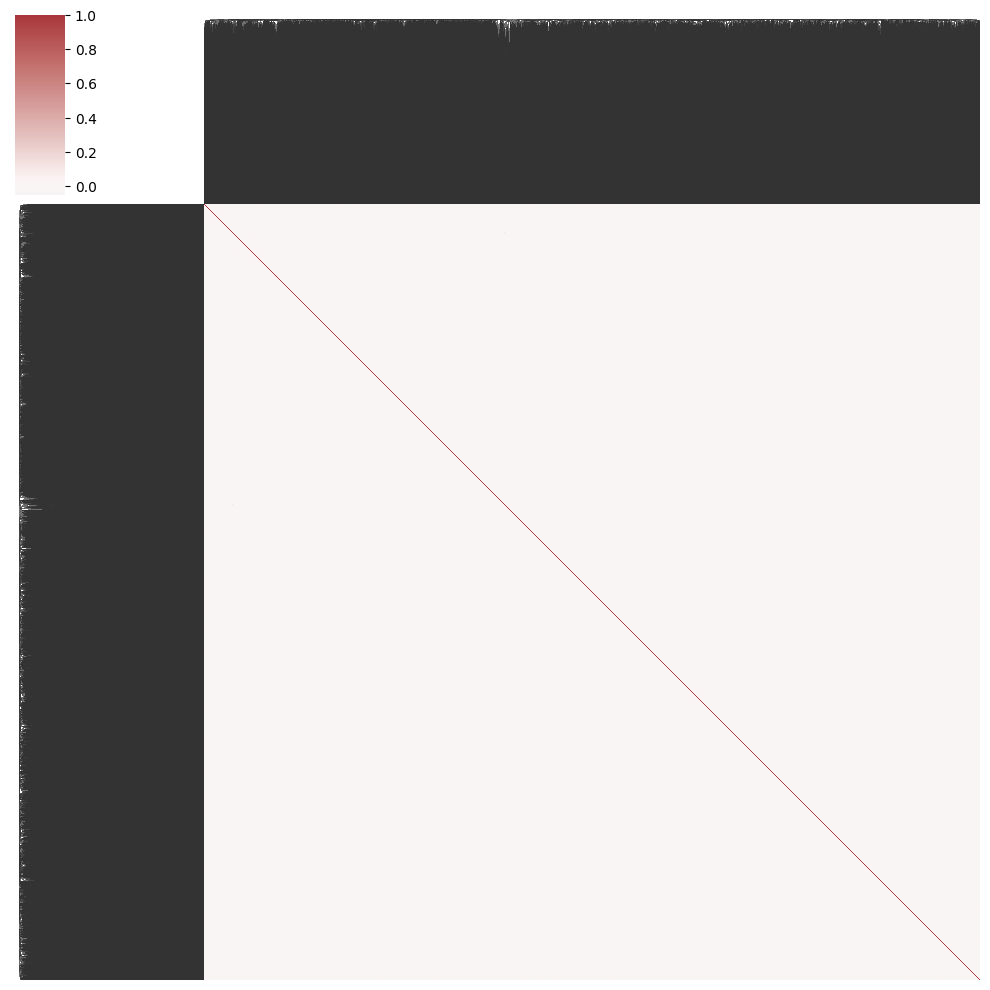

In [10]:
import numpy as np
import pandas as pd

data = np.load('src/lc_ksvd/outputs/sparse_codes/train_sparse_codes_frozen.npz')
Gamma = data['Gamma']
nz = (Gamma != 0).astype(np.float32)   # binary activation matrix, atoms x samples
atom_freq = nz.sum(axis=1)

# restrict to atoms used often enough for a stable correlation estimate
keep = np.where(atom_freq >= 50)[0]
X = nz[keep, :]          # (n_keep_atoms, n_samples)

corr = np.corrcoef(X)    # atoms x atoms Pearson correlation
corr_df = pd.DataFrame(corr, index=keep, columns=keep)
print(corr_df.shape)
import itertools

corr_vals = corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool)).stack()
top_pairs = corr_vals.sort_values(ascending=False).head(20)
print(top_pairs)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

dist = 1 - corr_df.values          # correlation -> distance (0 = identical pattern)
np.fill_diagonal(dist, 0)
dist = (dist + dist.T) / 2         # enforce exact symmetry (float rounding)
condensed = squareform(dist, checks=False)

Z = linkage(condensed, method='average')
cluster_ids = fcluster(Z, t=8, criterion='maxclust')   # cut into 8 clusters

g = sns.clustermap(
    corr_df, row_linkage=Z, col_linkage=Z,
    cmap='vlag', center=0, figsize=(10, 10),
    xticklabels=False, yticklabels=False,
)
g.savefig('correlation_clusters.png', dpi=150)


In [8]:
edge_thr = 20   # minimum shared-sample count to keep an edge
mask = (co.row < co.col) & (co.data >= edge_thr)

G = nx.Graph()
for i, j, w in zip(co.row[mask], co.col[mask], co.data[mask]):
    G.add_edge(int(keep[i]), int(keep[j]), weight=float(w))
G.remove_nodes_from(list(nx.isolates(G)))

communities = nx.algorithms.community.greedy_modularity_communities(G, weight='weight')
communities = sorted(communities, key=len, reverse=True)

print('num communities:', len(communities))
print('sizes:', [len(c) for c in communities])
for i, c in enumerate(communities[:8]):
    print(f'Cluster {i} (size {len(c)}):', sorted(c)[:20], '...')


num communities: 32
sizes: [149, 139, 128, 122, 117, 69, 60, 35, 13, 4, 4, 4, 4, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
Cluster 0 (size 149): [0, 35, 103, 127, 163, 255, 329, 477, 701, 884, 891, 991, 1082, 1130, 1146, 1181, 1188, 1221, 1226, 1270] ...
Cluster 1 (size 139): [30, 153, 179, 180, 288, 301, 317, 452, 468, 549, 558, 572, 635, 699, 713, 769, 807, 837, 859, 880] ...
Cluster 2 (size 128): [152, 243, 564, 658, 689, 746, 787, 967, 988, 1107, 1116, 1119, 1279, 1313, 1375, 1473, 1495, 1553, 1704, 1741] ...
Cluster 3 (size 122): [71, 183, 360, 383, 503, 543, 589, 615, 706, 748, 904, 997, 1027, 1180, 1195, 1333, 1423, 1441, 1507, 1603] ...
Cluster 4 (size 117): [131, 197, 242, 395, 434, 523, 535, 711, 843, 895, 934, 1042, 1043, 1067, 1306, 1439, 1492, 1606, 1788, 1808] ...
Cluster 5 (size 69): [10, 75, 106, 126, 165, 194, 265, 331, 342, 446, 560, 584, 654, 767, 851, 973, 1065, 1263, 1460, 1482] ...
Cluster 6 (size 60): [184, 202, 368, 568, 874, 1030, 1072, 1139, 117

18 clusters with >2 atoms, sizes: [149, 139, 128, 122, 117, 69, 60, 35, 13, 4, 4, 4, 4, 3, 3, 3, 3, 3]


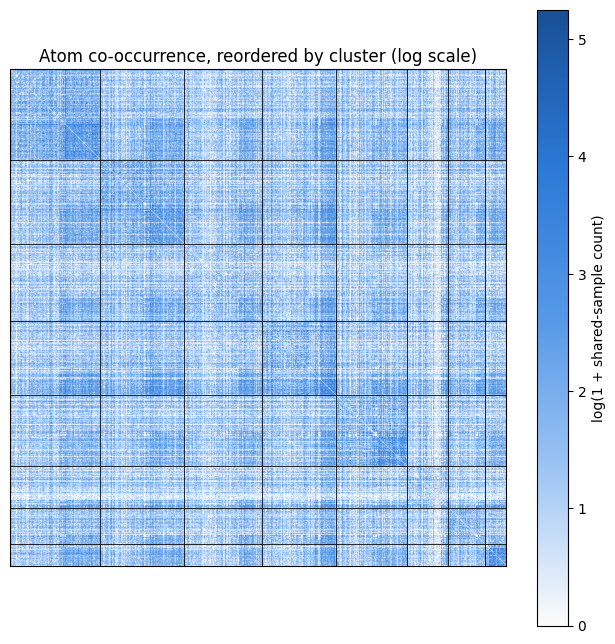

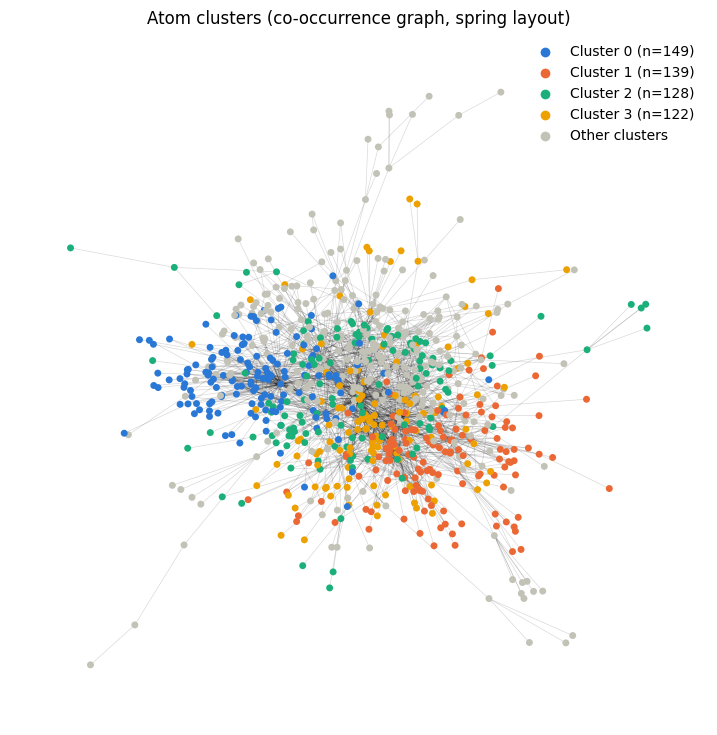

In [12]:
import numpy as np
import networkx as nx
from scipy import sparse

data = np.load('src/lc_ksvd/outputs/sparse_codes/train_sparse_codes_frozen.npz')
Gamma = data['Gamma']
nz = (Gamma != 0)
atom_freq = nz.sum(axis=1)
nz_sp = sparse.csr_matrix(nz.astype(np.int32))

HUB = 6498
keep = np.where(atom_freq >= 50)[0]
keep = keep[keep != HUB]

sub = nz_sp[keep, :]
co = sub.dot(sub.T).tocoo()

edge_thr = 20   # min shared-sample count to count as a real link
mask = (co.row < co.col) & (co.data >= edge_thr)

G = nx.Graph()
for i, j, w in zip(co.row[mask], co.col[mask], co.data[mask]):
    G.add_edge(int(keep[i]), int(keep[j]), weight=float(w))
G.remove_nodes_from(list(nx.isolates(G)))

communities = nx.algorithms.community.greedy_modularity_communities(G, weight='weight')
communities = [c for c in communities if len(c) > 2]          # keep only groups >2 atoms
communities = sorted(communities, key=len, reverse=True)

print(f'{len(communities)} clusters with >2 atoms, sizes: {[len(c) for c in communities]}')
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

top_clusters = communities[:8]
ordered_atoms = [a for c in top_clusters for a in sorted(c)]
idx_map = {a: i for i, a in enumerate(keep)}
pos_idx = [idx_map[a] for a in ordered_atoms]

co_csr = co.tocsr()
co_dense = co_csr[pos_idx, :][:, pos_idx].toarray()
co_dense = co_dense + co_dense.T  # co was upper-triangle-only when built from row<col mask above; rebuild symmetric
np.fill_diagonal(co_dense, 0)

seq_blue = LinearSegmentedColormap.from_list(
    'seq_blue', ['#fcfcfb', '#9ec5f4', '#5598e7', '#2a78d6', '#184f95']
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(np.log1p(co_dense), cmap=seq_blue)

# draw boundaries between clusters
boundary = 0
for c in top_clusters:
    boundary += len(c)
    ax.axhline(boundary - 0.5, color='#0b0b0b', linewidth=0.6)
    ax.axvline(boundary - 0.5, color='#0b0b0b', linewidth=0.6)

ax.set_title('Atom co-occurrence, reordered by cluster (log scale)')
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, label='log(1 + shared-sample count)')
plt.show()

top_n = 4  # only this many clusters get distinct colors; rest fold into "Other" (colorblind-safe cap)
palette = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
other_color = '#c3c2b7'

node_color = {}
for i, c in enumerate(communities):
    color = palette[i] if i < top_n else other_color
    for atom in c:
        node_color[atom] = color

# subgraph of just the plotted clusters, capped in size for a readable layout
plot_nodes = [a for c in communities[:8] for a in c]
Gsub = G.subgraph(plot_nodes)

pos = nx.spring_layout(Gsub, seed=42, weight='weight', k=0.15)
colors = [node_color[n] for n in Gsub.nodes()]

fig, ax = plt.subplots(figsize=(9, 9))
nx.draw_networkx_edges(Gsub, pos, alpha=0.15, width=0.5, ax=ax)
nx.draw_networkx_nodes(Gsub, pos, node_color=colors, node_size=25, linewidths=0, ax=ax)

for i in range(top_n):
    ax.scatter([], [], color=palette[i], label=f'Cluster {i} (n={len(communities[i])})')
ax.scatter([], [], color=other_color, label='Other clusters')
ax.legend(loc='upper right', frameon=False)
ax.set_title('Atom clusters (co-occurrence graph, spring layout)')
ax.axis('off')
plt.show()


In [22]:
nonzero_per_patch = np.count_nonzero(Gamma_normal, axis=0)

print("Average active atoms:",
      nonzero_per_patch.mean())

print("Median active atoms:",
      np.median(nonzero_per_patch))

print("Min:",
      nonzero_per_patch.min())

print("Max:",
      nonzero_per_patch.max())

Average active atoms: 7.741426882144265
Median active atoms: 10.0
Min: 0
Max: 10


In [23]:
atom_usage = np.count_nonzero(Gamma_normal, axis=1)

top_atoms = np.argsort(atom_usage)[::-1]

for i in top_atoms[:20]:
    print(
        f"Atom {i}: used by {atom_usage[i]} patches "
        f"({100*atom_usage[i]/Gamma_normal.shape[1]:.2f}%)"
    )

Atom 14811: used by 632 patches (1.56%)
Atom 27268: used by 388 patches (0.96%)
Atom 27441: used by 376 patches (0.93%)
Atom 25049: used by 363 patches (0.89%)
Atom 24966: used by 363 patches (0.89%)
Atom 25701: used by 361 patches (0.89%)
Atom 27170: used by 353 patches (0.87%)
Atom 27890: used by 350 patches (0.86%)
Atom 24594: used by 347 patches (0.85%)
Atom 25166: used by 343 patches (0.84%)
Atom 28141: used by 333 patches (0.82%)
Atom 28254: used by 327 patches (0.81%)
Atom 24964: used by 324 patches (0.80%)
Atom 28490: used by 321 patches (0.79%)
Atom 25968: used by 320 patches (0.79%)
Atom 25608: used by 318 patches (0.78%)
Atom 27395: used by 317 patches (0.78%)
Atom 28280: used by 317 patches (0.78%)
Atom 28602: used by 317 patches (0.78%)
Atom 25777: used by 315 patches (0.78%)


In [34]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/sparse_codes/train_sparse_codes.npz",
    allow_pickle=True
)

Gamma = data["Gamma"]
labels = data["labels"]

# Normal class
normal_idx = labels == 2
Gamma_normal = Gamma[:, normal_idx]

# Atom usage frequency
atom_usage = np.count_nonzero(Gamma_normal, axis=1)

top_atoms = np.argsort(atom_usage)[::-1]

print("Top atoms:")
for i in top_atoms[:20]:
    print(
        f"Atom {i}: "
        f"{atom_usage[i]} patches "
        f"({100*atom_usage[i]/Gamma_normal.shape[1]:.2f}%)"
    )

Top atoms:
Atom 14811: 632 patches (1.56%)
Atom 27268: 388 patches (0.96%)
Atom 27441: 376 patches (0.93%)
Atom 25049: 363 patches (0.89%)
Atom 24966: 363 patches (0.89%)
Atom 25701: 361 patches (0.89%)
Atom 27170: 353 patches (0.87%)
Atom 27890: 350 patches (0.86%)
Atom 24594: 347 patches (0.85%)
Atom 25166: 343 patches (0.84%)
Atom 28141: 333 patches (0.82%)
Atom 28254: 327 patches (0.81%)
Atom 24964: 324 patches (0.80%)
Atom 28490: 321 patches (0.79%)
Atom 25968: 320 patches (0.79%)
Atom 25608: 318 patches (0.78%)
Atom 27395: 317 patches (0.78%)
Atom 28280: 317 patches (0.78%)
Atom 28602: 317 patches (0.78%)
Atom 25777: 315 patches (0.78%)


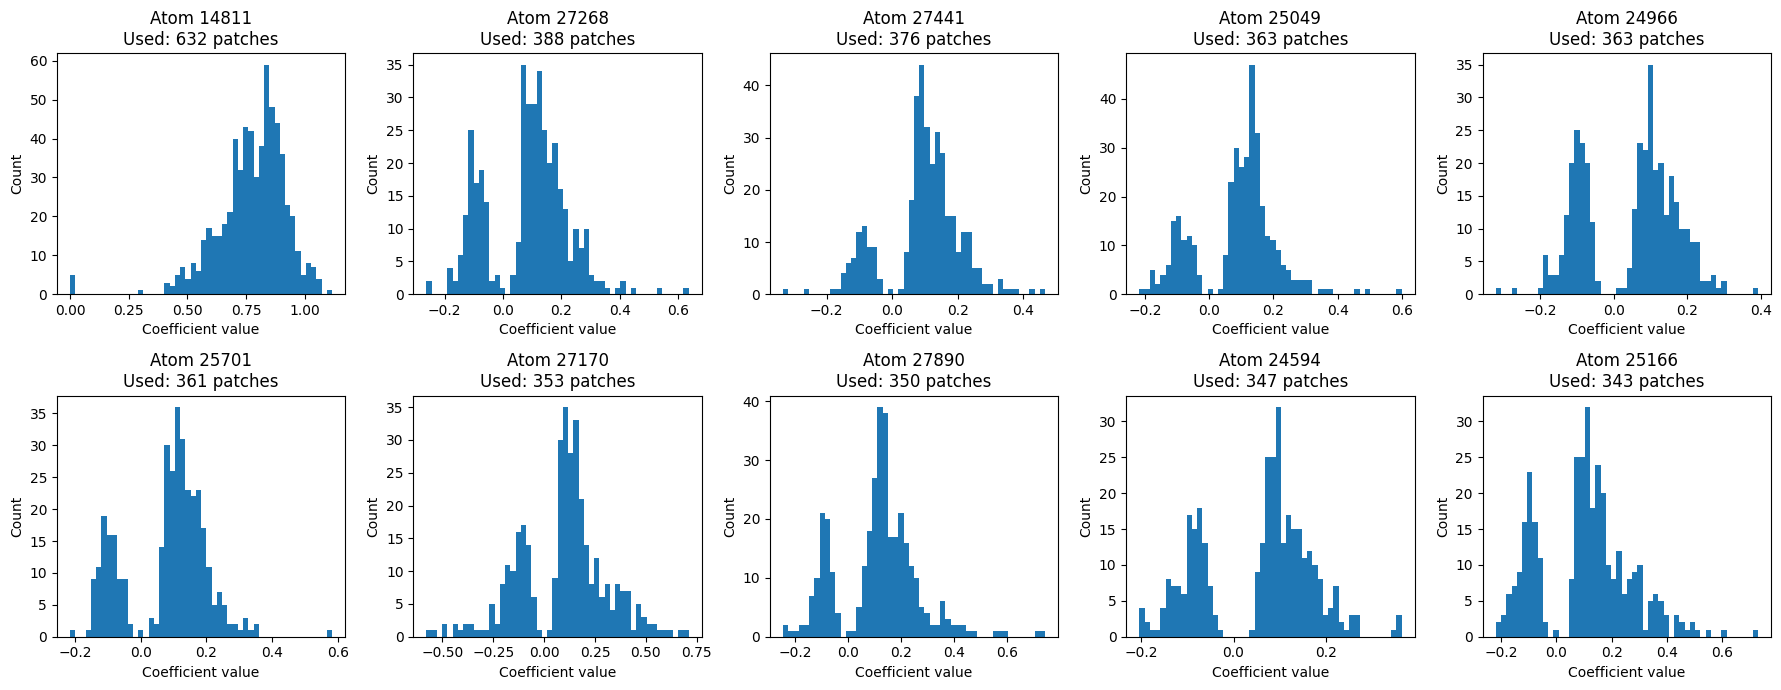

In [35]:
top_k = 10

fig, axes = plt.subplots(
    2,
    5,
    figsize=(18,7)
)

axes = axes.flatten()

for ax, atom in zip(
    axes,
    top_atoms[:top_k]
):

    # coefficients of this atom across normal patches
    coefficients = Gamma_normal[atom, :]

    # only active coefficients
    active_coeffs = coefficients[
        coefficients != 0
    ]

    ax.hist(
        active_coeffs,
        bins=50
    )

    ax.set_title(
        f"Atom {atom}\n"
        f"Used: {len(active_coeffs)} patches"
    )

    ax.set_xlabel("Coefficient value")
    ax.set_ylabel("Count")


plt.tight_layout()
plt.show()

Sparse codes shape: (28672, 117386)
Atom contribution shape: (28672,)


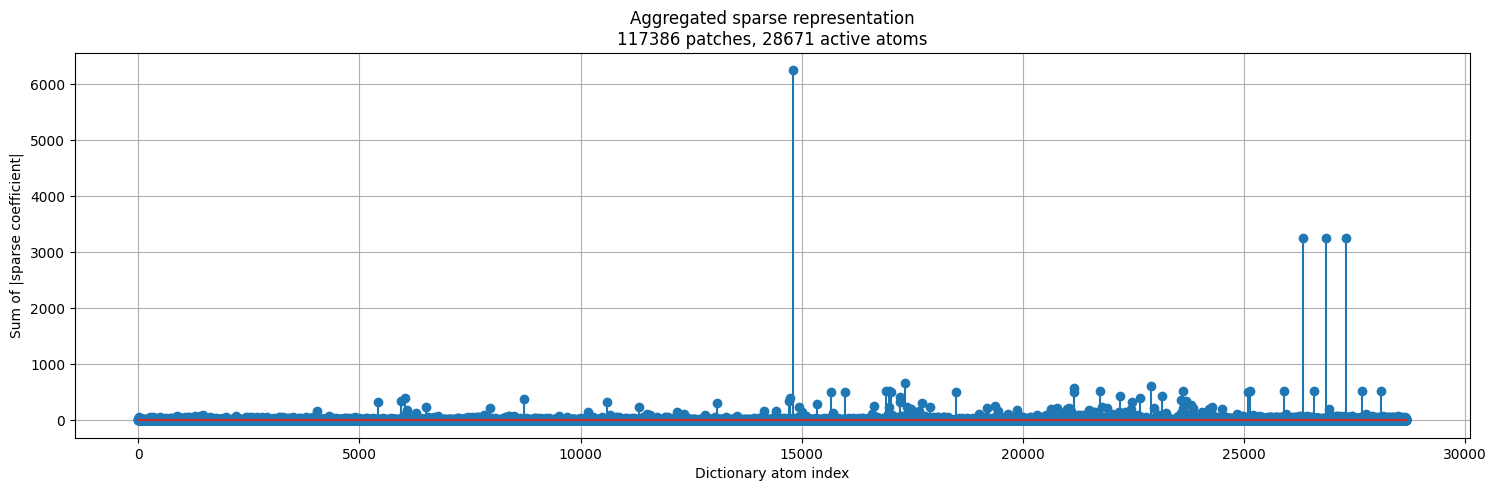

In [4]:
import numpy as np
import matplotlib.pyplot as plt

gamma_indices = np.arange(0, 117386)

# Extract sparse codes
Gamma_patches = Gamma[:, gamma_indices]

print("Sparse codes shape:", Gamma_patches.shape)

# Absolute coefficients
Gamma_abs = np.abs(Gamma_patches)

# Sum contribution of each atom across all patches
atom_contribution = np.sum(
    Gamma_abs,
    axis=1
)

print("Atom contribution shape:", atom_contribution.shape)


# Only plot atoms that contributed
active_atoms = np.where(atom_contribution > 0)[0]
active_values = atom_contribution[active_atoms]


plt.figure(figsize=(18,5))

plt.stem(
    active_atoms,
    active_values
)

plt.xlabel("Dictionary atom index")
plt.ylabel("Sum of |sparse coefficient|")
plt.title(
    f"Aggregated sparse representation\n"
    f"{len(gamma_indices)} patches, "
    f"{len(active_atoms)} active atoms"
)

plt.grid(True)
plt.show()

In [5]:
# Get top 10 contributing atoms
top_10_atoms = np.argsort(atom_contribution)[::-1][:10]

print("Top 10 atoms by summed |coefficient|:\n")

for atom in top_10_atoms:
    print(
        f"Atom {atom}: "
        f"Total |coefficient| = {atom_contribution[atom]:.6f}"
    )

Top 10 atoms by summed |coefficient|:

Atom 14811: Total |coefficient| = 6243.900989
Atom 27296: Total |coefficient| = 3257.594460
Atom 26844: Total |coefficient| = 3257.527581
Atom 26325: Total |coefficient| = 3257.527581
Atom 17329: Total |coefficient| = 669.332990
Atom 22904: Total |coefficient| = 613.163820
Atom 21148: Total |coefficient| = 566.147346
Atom 27668: Total |coefficient| = 517.624199
Atom 25143: Total |coefficient| = 516.835504
Atom 23618: Total |coefficient| = 516.721757


Top 4 atoms: [14811 27296 26844 26325 17329 22904 21148 27668 25143 23618]

Atom coefficients:
Atom 14811: 6226.458034
Atom 27296: -3257.460702
Atom 26844: -3257.527581
Atom 26325: -3257.527581
Atom 17329: 662.980558
Atom 22904: 605.507587
Atom 21148: 561.554772
Atom 27668: -514.883214
Atom 25143: -515.671909
Atom 23618: -515.785656

Combined patch shape: (4096,)


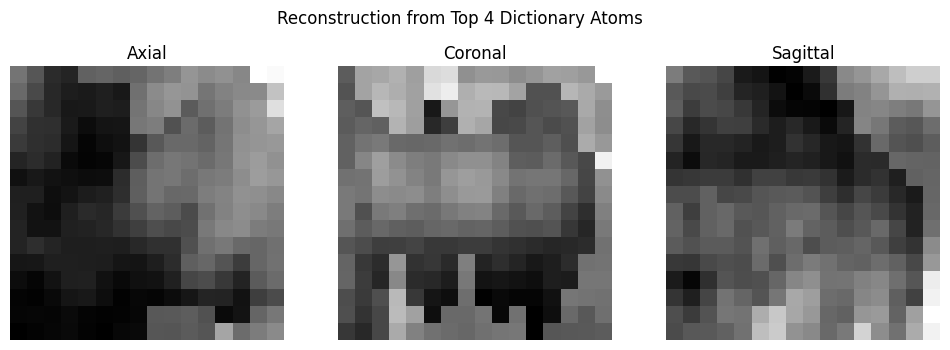

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

with open(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/models/unified_frozen.pkl",
    "rb"
) as f:
    model = pickle.load(f)

ksvd = model["model"]
D = ksvd.D_


# Take top 4 atoms from previous calculation
top_4_atoms = top_10_atoms[:10]

print("Top 4 atoms:", top_4_atoms)


# Aggregate coefficient for each selected atom
# (sum of signed coefficients across all patches)
atom_coefficients = np.sum(
    Gamma_patches[top_4_atoms, :],
    axis=1
)

print("\nAtom coefficients:")
for atom, coef in zip(top_4_atoms, atom_coefficients):
    print(f"Atom {atom}: {coef:.6f}")


# Reconstruct contribution of each atom
# D[:, atom] * coefficient
atom_contributions = []

for atom, coef in zip(top_4_atoms, atom_coefficients):

    patch = D[:, atom] * coef

    atom_contributions.append(
        patch
    )


# Superimpose the 4 atom contributions
combined_patch = np.sum(
    atom_contributions,
    axis=0
)


print("\nCombined patch shape:", combined_patch.shape)


# Convert to 3D
combined_patch_3d = combined_patch.reshape(
    16,16,16
)


# Visualize
mid = 8

fig, axes = plt.subplots(
    1,3,
    figsize=(12,4)
)

axes[0].imshow(
    combined_patch_3d[:,:,mid],
    cmap="gray"
)
axes[0].set_title("Axial")

axes[1].imshow(
    combined_patch_3d[:,mid,:],
    cmap="gray"
)
axes[1].set_title("Coronal")

axes[2].imshow(
    combined_patch_3d[mid,:,:],
    cmap="gray"
)
axes[2].set_title("Sagittal")


for ax in axes:
    ax.axis("off")

plt.suptitle(
    "Reconstruction from Top 4 Dictionary Atoms"
)

plt.show()

In [13]:
import numpy as np
import pickle

# Load sparse codes
sparse_data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/sparse_codes/train_sparse_codes.npz",
    allow_pickle=True
)

Gamma = sparse_data["Gamma"]

# Select 97992nd sparse code
idx = 97991
gamma = Gamma[:, idx]

print("Sparse code shape:", gamma.shape)


# Load dictionary
with open(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/models/unified_frozen.pkl",
    "rb"
) as f:
    model = pickle.load(f)

print(type(model))
print(model.keys() if isinstance(model, dict) else model)

Sparse code shape: (12096,)
<class 'dict'>
dict_keys(['model', 'algorithm', 'class_order', 'config', 'patch_size', 'target_spacing', 'hu_window', 'training_time_s'])


In [9]:
ksvd = model["model"]

print(type(ksvd))
print(ksvd.__dict__.keys())

<class 'reppi.dictionary.frozen.frozen.IncrementalFrozenDictionary'>
dict_keys(['base_learner_class', 'base_learner_kwargs', 'residual_learner_class', 'residual_learner_kwargs', 'n_nonzero_coefs', 'D_', 'base_class_label_', 'class_labels_', 'class_boundaries_', 'stage_learners_', 'errors_'])


In [10]:
print(ksvd.D_.shape)

(4096, 28672)


Dictionary shape: (4096, 28672)
Reconstructed patch shape: (4096,)


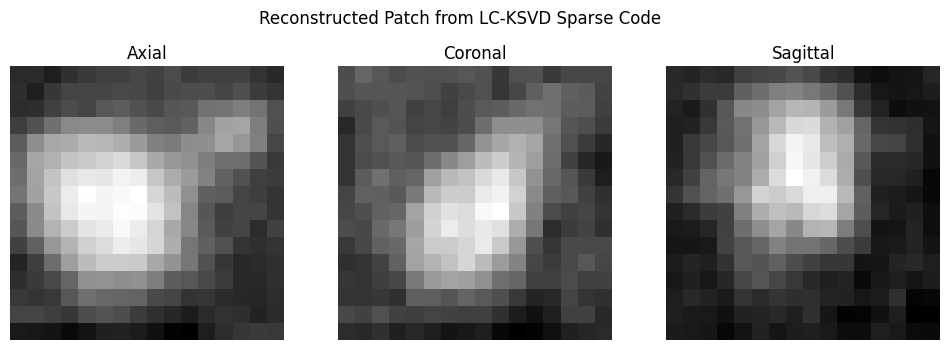

In [21]:
D = ksvd.D_

idx = 97991
gamma = Gamma[:, idx]

reconstructed_patch = D @ gamma

print("Dictionary shape:", D.shape)
print("Reconstructed patch shape:", reconstructed_patch.shape)

patch_3d = reconstructed_patch.reshape(16, 16, 16)

import matplotlib.pyplot as plt

# Choose center slices
mid = 8

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Axial view
axes[0].imshow(
    patch_3d[:, :, mid],
    cmap="gray"
)
axes[0].set_title("Axial")

# Coronal view
axes[1].imshow(
    patch_3d[:, mid, :],
    cmap="gray"
)
axes[1].set_title("Coronal")

# Sagittal view
axes[2].imshow(
    patch_3d[mid, :, :],
    cmap="gray"
)
axes[2].set_title("Sagittal")

for ax in axes:
    ax.axis("off")

plt.suptitle("Reconstructed Patch from LC-KSVD Sparse Code")
plt.show()

(1728, 11)
(11, 12, 12, 12)


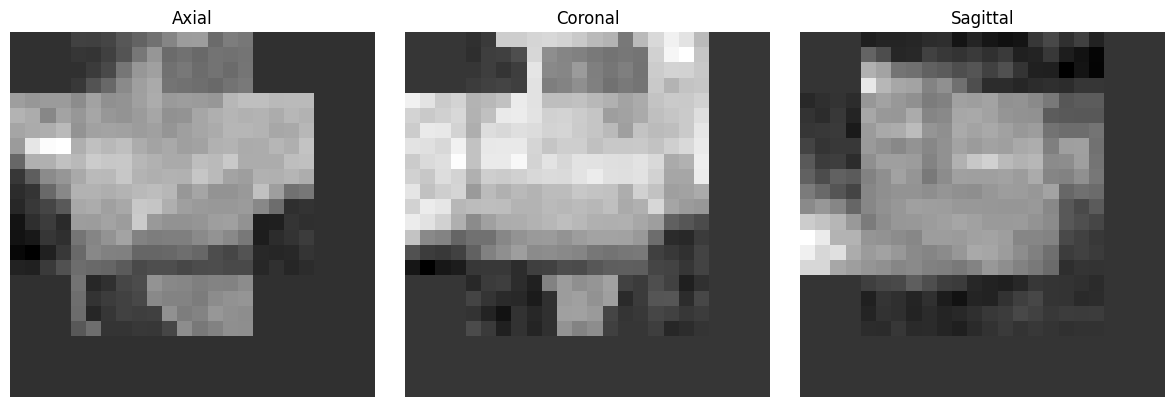

In [16]:
# Assumed sparse code indices
gamma_indices = np.arange(11751, 11762)

# Extract the 12 sparse codes
gamma = Gamma[:, gamma_indices]
ksvd = model["model"]
D = ksvd.D_
# Reconstruct all patches
reconstructed = D @ gamma

print(reconstructed.shape)

patches = reconstructed.T.reshape(-1, 12, 12, 12)

print(patches.shape)

coords12 = np.array([
    [61, 158, 116],
    [61, 158, 120],
    [65, 154, 116],
    [65, 154, 120],
    [65, 158, 112],
    [65, 158, 116],
    [65, 158, 120],
    [65, 162, 116],
    [65, 162, 120],
    [69, 158, 116],
    [69, 158, 120],
    [69, 162, 116]
])

min_coord = coords12.min(axis=0)
max_coord = coords12.max(axis=0)

shape = tuple(max_coord - min_coord + 16)

volume = np.zeros(shape)
weight = np.zeros(shape)

for patch, coord in zip(patches, coords12):

    x, y, z = coord - min_coord

    volume[x:x+12, y:y+12, z:z+12] += patch
    weight[x:x+12, y:y+12, z:z+12] += 1

volume /= np.maximum(weight, 1)

# Visualize the reconstructed volume

import matplotlib.pyplot as plt

cx, cy, cz = np.array(volume.shape) // 2

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(volume[:, :, cz], cmap="gray")
ax[0].set_title("Axial")

ax[1].imshow(volume[:, cy, :], cmap="gray")
ax[1].set_title("Coronal")

ax[2].imshow(volume[cx, :, :], cmap="gray")
ax[2].set_title("Sagittal")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

In [10]:
import numpy as np

data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_test_normal.npz",
    allow_pickle=True
)

scan_ids = data["scan_ids"]

print("Shape:", scan_ids.shape)
print("Type:", type(scan_ids))
print("Dtype:", scan_ids.dtype)

print("Total scan IDs:", scan_ids.shape[0])
print("Unique scan IDs:", np.unique(scan_ids))
print("Number of unique scan IDs:", len(np.unique(scan_ids)))

Shape: (5850,)
Type: <class 'numpy.ndarray'>
Dtype: object
Total scan IDs: 5850
Unique scan IDs: ['train_12132_a_2' 'train_14336_a_2' 'train_15753_a_2' 'train_15829_a_1'
 'train_16003_a_2' 'train_16110_a_1' 'train_16404_a_1' 'train_17370_a_1'
 'train_17896_b_2' 'train_18107_a_2' 'train_19798_a_2' 'train_2510_a_1'
 'train_3994_a_1' 'train_4335_a_2' 'train_437_a_1' 'train_5425_a_2'
 'train_5864_b_1' 'train_5977_a_2' 'train_6321_b_2' 'train_783_a_2'
 'train_8143_a_1']
Number of unique scan IDs: 21


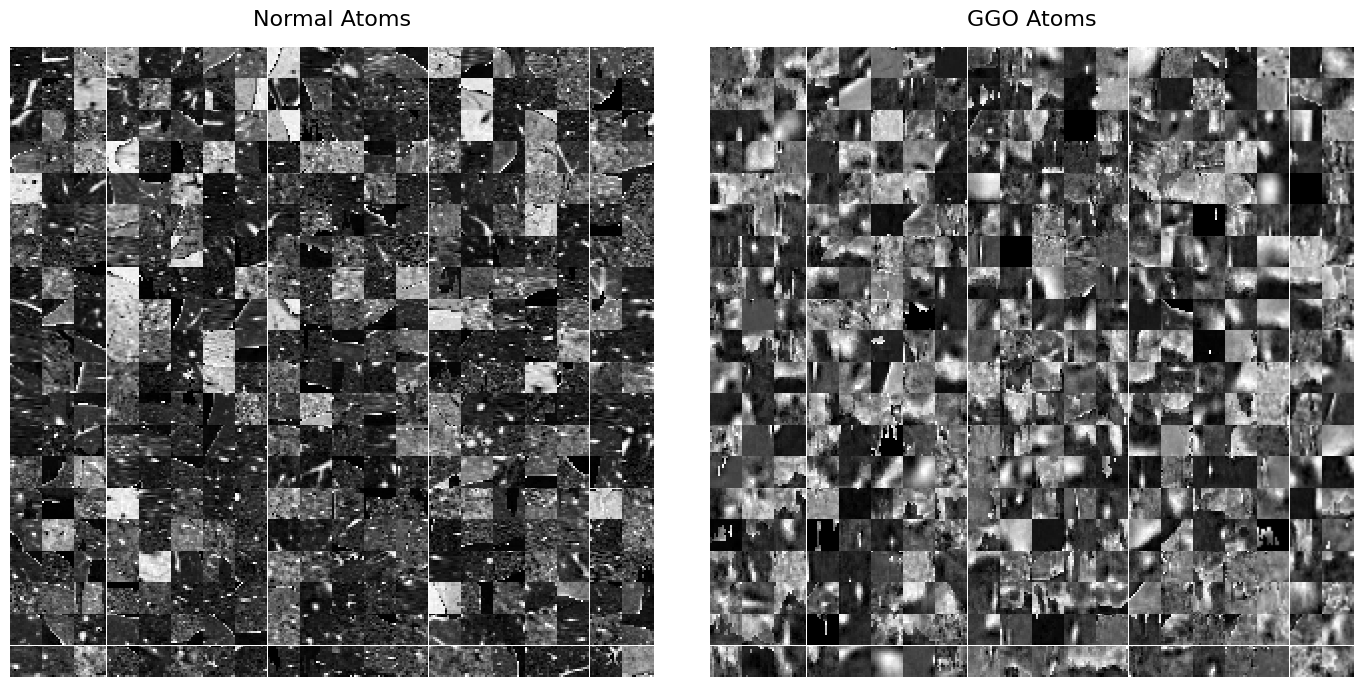

In [21]:
import numpy as np
import matplotlib.pyplot as plt

PATCH_SIZE = 16
MIDDLE = PATCH_SIZE // 2

rng = np.random.default_rng(42)

# Select 400 random atoms from each class
normal_atoms = rng.choice(
    np.arange(0, 16384),
    size=400,
    replace=False
)

ggo_atoms = rng.choice(
    np.arange(16384, 24576),
    size=400,
    replace=False
)


def plot_grid(fig, left, right, atom_ids, title):

    gs = fig.add_gridspec(
        20,
        20,
        left=left,
        right=right,
        top=0.92,
        bottom=0.02,
        wspace=0,
        hspace=0
    )

    axes = []

    for i in range(20):
        for j in range(20):
            ax = fig.add_subplot(gs[i, j])
            ax.axis("off")
            axes.append(ax)

    fig.text(
        (left + right) / 2,
        0.95,
        title,
        ha="center",
        fontsize=16
    )

    for ax, atom_id in zip(axes, atom_ids):

        atom = D[:, atom_id].reshape(
            PATCH_SIZE,
            PATCH_SIZE,
            PATCH_SIZE
        )

        ax.imshow(
            atom[MIDDLE],
            cmap="gray"
        )

        ax.axis("off")


fig = plt.figure(figsize=(14, 7))


# Normal atoms
plot_grid(
    fig,
    0.02,
    0.48,
    normal_atoms,
    "Normal Atoms"
)


# GGO atoms
plot_grid(
    fig,
    0.52,
    0.98,
    ggo_atoms,
    "GGO Atoms"
)


plt.show()

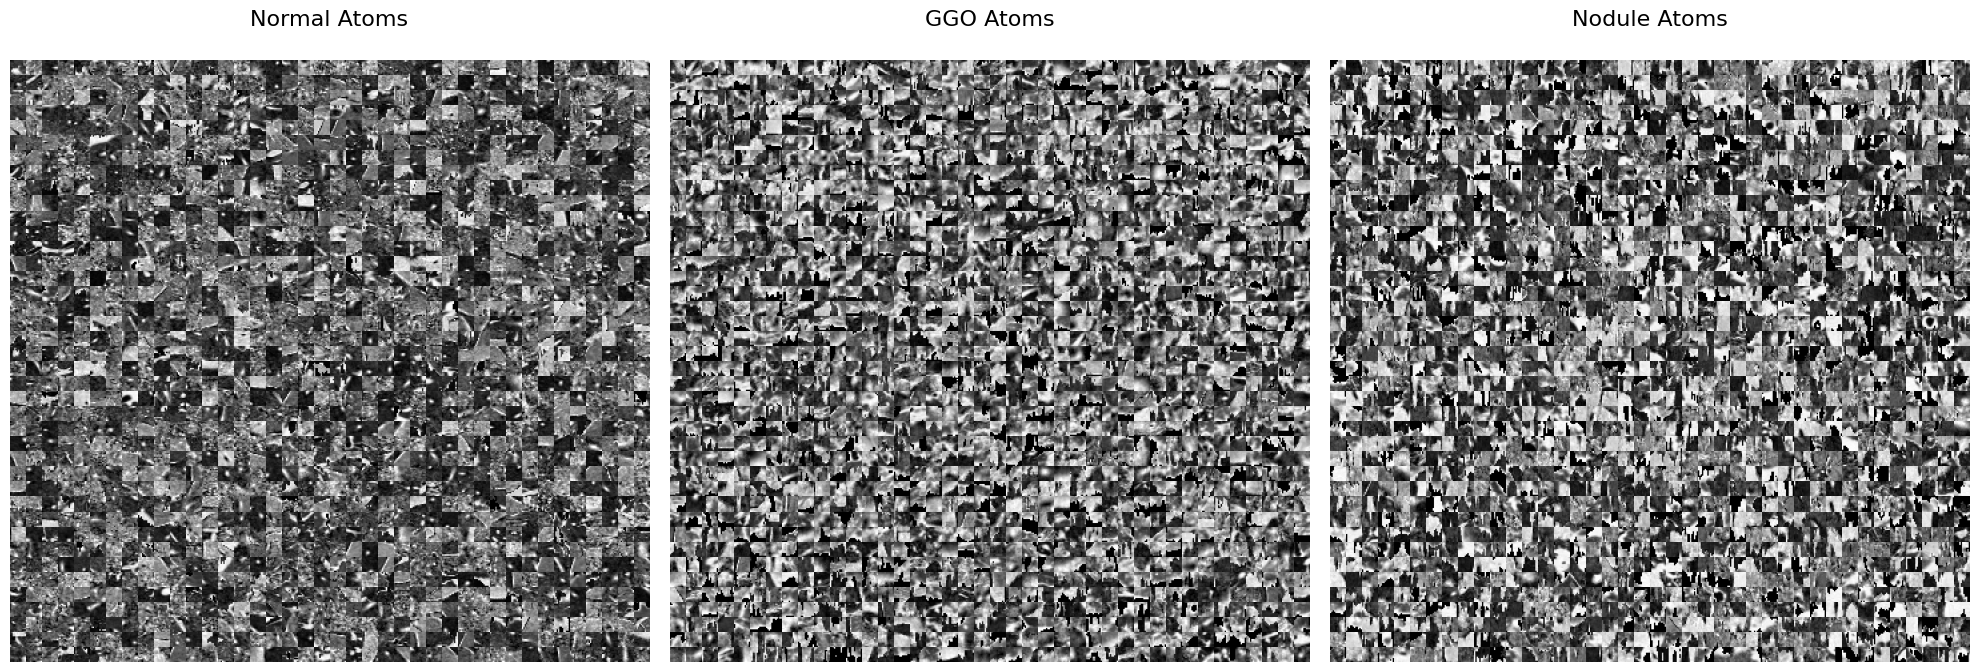

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

D = pickle.load(
    open(
        "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/models/unified_frozen.pkl",
        "rb"
    ))["model"].D_

PATCH_SIZE = 12
MIDDLE = PATCH_SIZE // 2

rng = np.random.default_rng(42)

GRID_SIZE = 40
N_ATOMS = GRID_SIZE * GRID_SIZE  # 900

normal_atoms = rng.choice(
    np.arange(0, 6812),
    size=N_ATOMS,
    replace=False
)

ggo_atoms = rng.choice(
    np.arange(6912, 10368),
    size=N_ATOMS,
    replace=False
)

nodule_atoms = rng.choice(
    np.arange(10368, 12096),
    size=N_ATOMS,
    replace=False
)

def plot_grid(fig, left, right, atom_ids, title):

    gs = fig.add_gridspec(
        GRID_SIZE,
        GRID_SIZE,
        left=left,
        right=right,
        top=0.88,
        bottom=0.02,
        wspace=0,
        hspace=0
    )

    axes = []

    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            ax = fig.add_subplot(gs[i, j])
            ax.axis("off")
            axes.append(ax)

    fig.text(
        (left + right) / 2,
        0.93,
        title,
        ha="center",
        fontsize=16
    )

    for ax, atom_id in zip(axes, atom_ids):
        atom = D[:, atom_id].reshape(
            PATCH_SIZE,
            PATCH_SIZE,
            PATCH_SIZE
        )

        ax.imshow(atom[MIDDLE], cmap="gray")
        ax.axis("off")


fig = plt.figure(figsize=(20, 7))


# Normal atoms
plot_grid(
    fig,
    0.01,
    0.33,
    normal_atoms,
    "Normal Atoms"
)


# GGO atoms
plot_grid(
    fig,
    0.34,
    0.66,
    ggo_atoms,
    "GGO Atoms"
)


# Nodule atoms
plot_grid(
    fig,
    0.67,
    0.99,
    nodule_atoms,
    "Nodule Atoms"
)


plt.show()

In [1]:
import numpy as np
import pickle

# Load dictionary
D = pickle.load(
    open(
        "/models/lc-ksvd/src/lc_ksvd/outputs/unified_frozen.pkl",
        "rb"
    )
)["model"].D_

# Normalize columns
D = D / np.linalg.norm(D, axis=0, keepdims=True)

def mutual_coherence(dictionary):
    """
    Compute mutual coherence of a dictionary.

    Returns
    -------
    mu : float
        Maximum absolute off-diagonal inner product.
    G : ndarray
        Absolute Gram matrix.
    """

    G = np.abs(dictionary.T @ dictionary)

    np.fill_diagonal(G, 0)

    mu = G.mean()

    return mu, G

mu_total, G_total = mutual_coherence(D)

normal_D = D[:, 0:6812]
ggo_D = D[:, 6912:10368]
nodule_D = D[:, 10368:12096]

mu_normal, _ = mutual_coherence(normal_D)
mu_ggo, _ = mutual_coherence(ggo_D)
mu_nodule, _ = mutual_coherence(nodule_D)

def cross_coherence(D1, D2):
    return np.mean(np.abs(D1.T @ D2))

print("=" * 45)
print("Mutual Coherence")
print("=" * 45)
print(f"Whole Dictionary : {mu_total:.4f}")
print(f"Normal           : {mu_normal:.4f}")
print(f"GGO              : {mu_ggo:.4f}")
print(f"Nodule           : {mu_nodule:.4f}")
print()
print("Cross Coherence")
print("-" * 45)
print(f"Normal-GGO       : {cross_coherence(normal_D, ggo_D):.4f}")
print(f"Normal-Nodule    : {cross_coherence(normal_D, nodule_D):.4f}")
print(f"GGO-Nodule       : {cross_coherence(ggo_D, nodule_D):.4f}")

FileNotFoundError: [Errno 2] No such file or directory: '/models/lc-ksvd/src/lc_ksvd/outputs/unified_frozen.pkl'

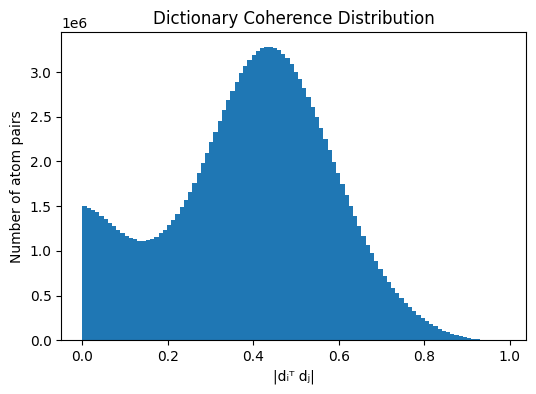

Mean   : 0.3932540480172516
Median : 0.40953360876296285
95th % : 0.6839114856311697
99th % : 0.7889874071902298
Maximum: 0.9896776675456002


In [3]:
import matplotlib.pyplot as plt

G = np.abs(D.T @ D)
np.fill_diagonal(G, np.nan)

values = G[~np.isnan(G)]

plt.figure(figsize=(6,4))
plt.hist(values, bins=100)
plt.xlabel("|dᵢᵀ dⱼ|")
plt.ylabel("Number of atom pairs")
plt.title("Dictionary Coherence Distribution")
plt.show()

print("Mean   :", np.mean(values))
print("Median :", np.median(values))
print("95th % :", np.percentile(values, 95))
print("99th % :", np.percentile(values, 99))
print("Maximum:", np.max(values))

Total CTs: 347


Processing CTs: 100%|██████████| 347/347 [27:55<00:00,  4.83s/it] 



Saved: normal_lung_voxels_with_meta.npz
Total CTs saved: 347

Example CT:
CT name: train_12342_a_1
Voxel shape: (647180,)


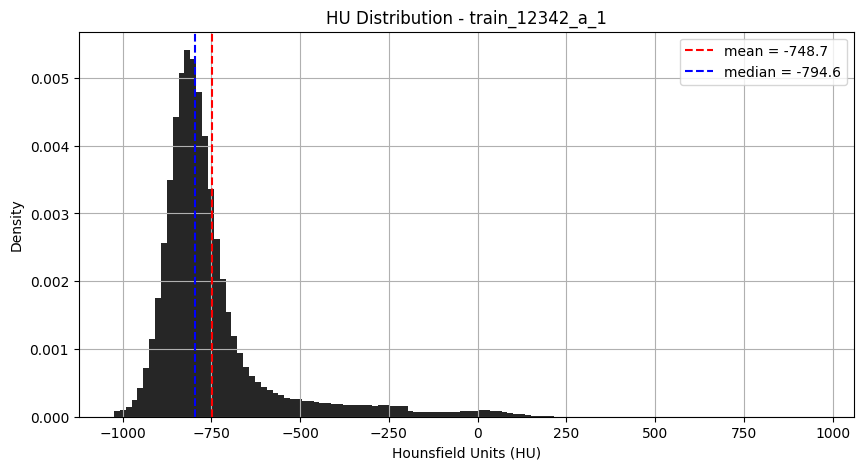

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.segmentation import clear_border
from tqdm import tqdm

from lc_ksvd.data_loader import LabelRegistry, MetadataRegistry, load_volume, resample_volume
from lc_ksvd.config import HU_MIN, HU_MAX


# -------------------------------------------------------
# Lung mask
# -------------------------------------------------------
def build_lung_mask(vol):
    mask = (vol >= HU_MIN) & (vol <= HU_MAX)

    mask_clear = np.zeros_like(mask, dtype=bool)

    for z in range(mask.shape[2]):
        mask_clear[:, :, z] = clear_border(mask[:, :, z])

    labels, num = ndimage.label(mask_clear)

    if num > 0:
        sizes = ndimage.sum(mask_clear, labels, range(1, num + 1))

        if len(sizes) >= 2:
            largest_two = np.argsort(sizes)[-2:] + 1
            lung_mask = np.isin(labels, largest_two)
        else:
            lung_mask = labels > 0
    else:
        lung_mask = mask_clear

    structure = ndimage.generate_binary_structure(3, 2)
    lung_mask = ndimage.binary_closing(lung_mask, structure=structure, iterations=2)
    lung_mask = ndimage.binary_fill_holes(lung_mask)

    return lung_mask


# -------------------------------------------------------
# Init
# -------------------------------------------------------
metadata = MetadataRegistry(split=None)
labels = LabelRegistry(metadata, split=None)

normal_volume_names = labels.get_normal_volume_names()

print("Total CTs:", len(normal_volume_names))


# -------------------------------------------------------
# Store per CT
# -------------------------------------------------------
dataset = []


# -------------------------------------------------------
# Process CTs
# -------------------------------------------------------
for volume_name in tqdm(normal_volume_names, desc="Processing CTs"):

    try:
        vol_hu, spacing = load_volume(volume_name)
        vol_rs = resample_volume(vol_hu, spacing)

        lung_mask = build_lung_mask(vol_rs)
        lung_voxels = vol_rs[lung_mask].astype(np.float32)

        if lung_voxels.size == 0:
            continue

        dataset.append({
            "ct_name": volume_name,
            "voxels": lung_voxels
        })

    except Exception as e:
        print(f"Skipped {volume_name}: {e}")


# -------------------------------------------------------
# Save NPZ (with metadata)
# -------------------------------------------------------
output_file = "normal_lung_voxels_with_meta.npz"

np.savez_compressed(
    output_file,
    data=np.array(dataset, dtype=object)
)

print("\nSaved:", output_file)
print("Total CTs saved:", len(dataset))


# -------------------------------------------------------
# Load back example (test)
# -------------------------------------------------------
loaded = np.load(output_file, allow_pickle=True)
records = loaded["data"]

print("\nExample CT:")
print("CT name:", records[0]["ct_name"])
print("Voxel shape:", records[0]["voxels"].shape)


# -------------------------------------------------------
# Plot one CT HU distribution
# -------------------------------------------------------
voxels = records[0]["voxels"]

plt.figure(figsize=(10, 5))

plt.hist(voxels, bins=120, density=True, alpha=0.85, color="black")

plt.axvline(voxels.mean(), color="red", linestyle="--",
            label=f"mean = {voxels.mean():.1f}")

plt.axvline(np.median(voxels), color="blue", linestyle="--",
            label=f"median = {np.median(voxels):.1f}")

plt.title(f"HU Distribution - {records[0]['ct_name']}")
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

In [6]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.segmentation import clear_border
from tqdm import tqdm

%pip install -q -e /home/chest_ct/code/models/lc-ksvd
sys.path.insert(0, "/home/chest_ct/code/models/lc-ksvd/src")

from lc_ksvd.config import HU_MIN, HU_MAX
from lc_ksvd.data_loader import LabelRegistry, MetadataRegistry, load_volume, resample_volume

print(">>> SCRIPT STARTED")
# -------------------------------------------------------
# Lung mask (your method)
# -------------------------------------------------------
def build_lung_mask(vol):
    mask = (vol >= HU_MIN) & (vol <= HU_MAX)

    mask_clear = np.zeros_like(mask, dtype=bool)
    for z in range(mask.shape[2]):
        mask_clear[:, :, z] = clear_border(mask[:, :, z])

    labels, num = ndimage.label(mask_clear)

    if num > 0:
        sizes = ndimage.sum(mask_clear, labels, range(1, num + 1))

        if len(sizes) >= 2:
            largest_two = np.argsort(sizes)[-2:] + 1
            lung_mask = np.isin(labels, largest_two)
        else:
            lung_mask = labels > 0
    else:
        lung_mask = mask_clear

    structure = ndimage.generate_binary_structure(3, 2)
    lung_mask = ndimage.binary_closing(lung_mask, structure=structure, iterations=2)
    lung_mask = ndimage.binary_fill_holes(lung_mask)

    return lung_mask


# -------------------------------------------------------
# Init
# -------------------------------------------------------
metadata = MetadataRegistry(split=None)
labels = LabelRegistry(metadata, split=None)

abnormalities = ["2b", "2c", "2d"]

output_dir = Path("/home/chest_ct/code/models/lc-ksvd/eda_outputs/npz_voxels")
output_dir.mkdir(parents=True, exist_ok=True)

bins = np.arange(-1000, 251, 10)


# -------------------------------------------------------
# MAIN LOOP
# -------------------------------------------------------
for category in abnormalities:

    print(f"\nProcessing category: {category}")

    volume_names = labels.get_positive_volume_names(category)

    all_lung_voxels = []

    # ---------------------------
    # Collect voxels
    # ---------------------------
    for volume_name in tqdm(volume_names, desc=f"Processing {category}", unit="vol"):

        try:
            vol_hu, spacing = load_volume(volume_name)
            vol_rs = resample_volume(vol_hu, spacing)

            lung_mask = build_lung_mask(vol_rs)
            lung_voxels = vol_rs[lung_mask].astype(np.float32)

            if lung_voxels.size > 0:
                all_lung_voxels.append(lung_voxels)

        except Exception as e:
            print(f"Skipped {volume_name}: {e}")

    if not all_lung_voxels:
        print(f"No data for {category}")
        continue

    # ---------------------------
    # Merge voxels
    # ---------------------------
    all_lung_voxels = np.concatenate(all_lung_voxels).astype(np.float32)

    print(f"{category}: total voxels = {all_lung_voxels.size:,}")

    # ---------------------------
    # Save npz
    # ---------------------------
    save_path = output_dir / f"{category}_lung_voxels.npz"

    np.savez_compressed(save_path, voxels=all_lung_voxels)

    print(f"Saved: {save_path}")

    # ---------------------------
    # Plot distribution
    # ---------------------------
    plt.figure(figsize=(10, 5))

    hist, _ = np.histogram(all_lung_voxels, bins=bins, density=True)

    plt.plot(bins[:-1], hist, linewidth=2, label=f"{category}")

    plt.axvline(all_lung_voxels.mean(), color="red", linestyle="--",
                label=f"mean = {all_lung_voxels.mean():.1f}")

    plt.axvline(np.median(all_lung_voxels), color="blue", linestyle="--",
                label=f"median = {np.median(all_lung_voxels):.1f}")

    plt.title(f"HU Distribution (Lung Voxels) - {category}")
    plt.xlabel("Hounsfield Units (HU)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

>>> SCRIPT STARTED

Processing category: 2b


Processing 2b: 0vol [00:00, ?vol/s]


No data for 2b

Processing category: 2c


Processing 2c:   3%|▎         | 33/1176 [01:31<52:50,  2.77s/vol]


KeyboardInterrupt: 

Total CT scans: 347

===== GLOBAL HU STATISTICS =====
Total voxels: 512,300,757
Min HU: -29001.77
Mean HU: -789.81
Median HU: -846.92
Max HU: 29808.06

Percentiles:
P1: -1010.27
P5: -954.96
P25: -890.66
P50: -846.92
P75: -769.66
P95: -350.17
P99: -28.53

===== PER-CT SUMMARY (first 5) =====

CT: train_12342_a_1
  Voxels: 647,180
  Min/Mean/Median/Max: -1024.0 / -748.7 / -794.6 / 960.1

CT: train_10990_a_1
  Voxels: 1,798,687
  Min/Mean/Median/Max: -1024.0 / -841.5 / -888.7 / 3071.0

CT: train_9664_a_1
  Voxels: 1,203,990
  Min/Mean/Median/Max: -1024.0 / -736.4 / -788.2 / 628.7

CT: train_2863_a_1
  Voxels: 1,340,260
  Min/Mean/Median/Max: -1023.9 / -763.3 / -819.7 / 320.8

CT: train_5462_a_2
  Voxels: 3,010,804
  Min/Mean/Median/Max: -1024.0 / -848.0 / -893.5 / 1177.1


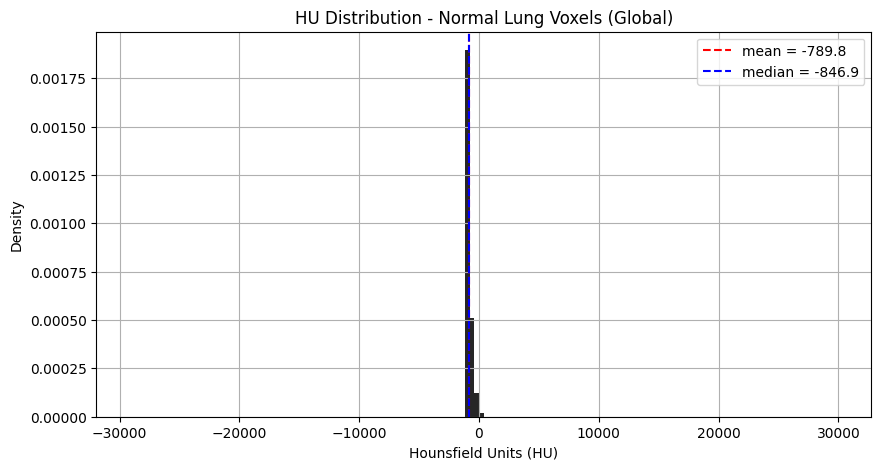

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Load dataset
# -------------------------------------------------------
file_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/normal_lung_voxels_with_meta.npz"

data = np.load(file_path, allow_pickle=True)
records = data["data"]

print("Total CT scans:", len(records))


# -------------------------------------------------------
# Collect all voxels (global distribution)
# -------------------------------------------------------
all_voxels = np.concatenate([r["voxels"] for r in records]).astype(np.float32)

print("\n===== GLOBAL HU STATISTICS =====")
print(f"Total voxels: {all_voxels.size:,}")
print(f"Min HU: {all_voxels.min():.2f}")
print(f"Mean HU: {all_voxels.mean():.2f}")
print(f"Median HU: {np.median(all_voxels):.2f}")
print(f"Max HU: {all_voxels.max():.2f}")

print("\nPercentiles:")
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"P{p}: {np.percentile(all_voxels, p):.2f}")


# -------------------------------------------------------
# Per-CT statistics
# -------------------------------------------------------
print("\n===== PER-CT SUMMARY (first 5) =====")

for r in records[:5]:
    v = r["voxels"]
    print(f"\nCT: {r['ct_name']}")
    print(f"  Voxels: {v.size:,}")
    print(f"  Min/Mean/Median/Max: "
          f"{v.min():.1f} / {v.mean():.1f} / {np.median(v):.1f} / {v.max():.1f}")


# -------------------------------------------------------
# Histogram (global)
# -------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.hist(all_voxels, bins=150, density=True, alpha=0.85, color="black")

plt.axvline(all_voxels.mean(), color="red", linestyle="--",
            label=f"mean = {all_voxels.mean():.1f}")

plt.axvline(np.median(all_voxels), color="blue", linestyle="--",
            label=f"median = {np.median(all_voxels):.1f}")

plt.title("HU Distribution - Normal Lung Voxels (Global)")
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

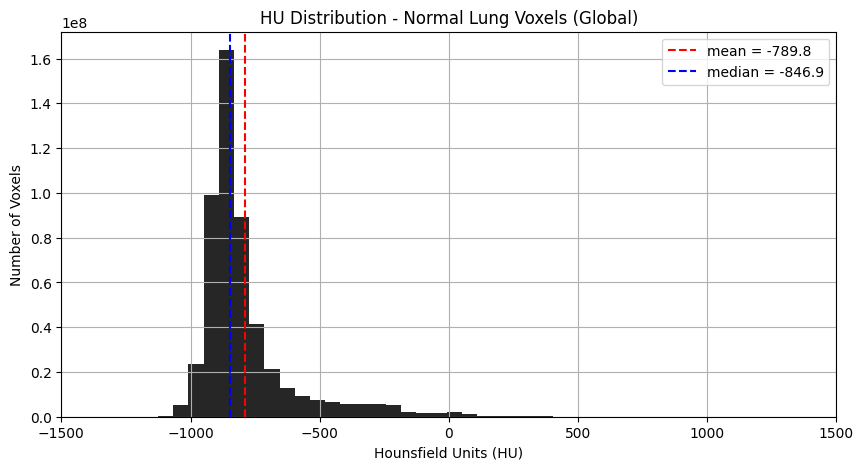

In [16]:
# -------------------------------------------------------
# Histogram (global - voxel counts)
# -------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.hist(all_voxels, bins=1000, alpha=0.85, color="black")

plt.axvline(all_voxels.mean(), color="red", linestyle="--",
            label=f"mean = {all_voxels.mean():.1f}")

plt.axvline(np.median(all_voxels), color="blue", linestyle="--",
            label=f"median = {np.median(all_voxels):.1f}")

plt.title("HU Distribution - Normal Lung Voxels (Global)")
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Number of Voxels")   # changed

plt.xlim(-1500,1500)

plt.legend()
plt.grid(True)

plt.show()

In [8]:
import numpy as np

file_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/normal_lung_voxels_with_meta.npz"

data = np.load(file_path, allow_pickle=True)
records = data["data"]

bad_cts = []

# -------------------------------------------------------
# Scan per CT
# -------------------------------------------------------
for r in records:

    voxels = r["voxels"]

    min_v = float(voxels.min())
    max_v = float(voxels.max())

    # threshold for abnormal CT intensity
    if min_v < -1024 or max_v > 3071:
        bad_cts.append({
            "ct_name": r["ct_name"],
            "min": min_v,
            "max": max_v,
            "voxels": voxels.size
        })


# -------------------------------------------------------
# Sort by worst extreme value
# -------------------------------------------------------
bad_cts_sorted = sorted(
    bad_cts,
    key=lambda x: max(abs(x["min"]), abs(x["max"])),
    reverse=True
)


# -------------------------------------------------------
# Print results
# -------------------------------------------------------
print("===== EXTREME CT SCANS =====")
print(f"Total bad CTs: {len(bad_cts_sorted)}\n")

for c in bad_cts_sorted[:20]:
    print(f"CT: {c['ct_name']}")
    print(f"  Min HU: {c['min']:.1f}")
    print(f"  Max HU: {c['max']:.1f}")
    print(f"  Voxels: {c['voxels']:,}")
    print("-" * 40)

===== EXTREME CT SCANS =====
Total bad CTs: 73

CT: train_136_a_2
  Min HU: -29001.8
  Max HU: 29808.1
  Voxels: 1,550,125
----------------------------------------
CT: train_9186_a_2
  Min HU: -4070.3
  Max HU: 28247.3
  Voxels: 1,153,184
----------------------------------------
CT: train_13441_a_2
  Min HU: -1024.0
  Max HU: 27554.0
  Voxels: 1,683,685
----------------------------------------
CT: train_12958_a_2
  Min HU: -11584.0
  Max HU: 26201.3
  Voxels: 1,385,587
----------------------------------------
CT: train_18518_a_2
  Min HU: -4135.8
  Max HU: 26154.6
  Voxels: 1,614,320
----------------------------------------
CT: train_19847_a_2
  Min HU: -4101.8
  Max HU: 22922.2
  Voxels: 1,299,852
----------------------------------------
CT: train_4255_a_2
  Min HU: -1024.0
  Max HU: 22365.3
  Voxels: 1,542,150
----------------------------------------
CT: train_5977_a_2
  Min HU: -2472.4
  Max HU: 19390.8
  Voxels: 737,412
----------------------------------------
CT: train_19464_a_2
 